# Poziom 2 - Transformacja danych

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
warnings.filterwarnings(
    "ignore",
    message="Using the boxplot function without specifying `order` is likely to produce an incorrect plot."
)

pd.options.display.float_format = "{:,.2f}".format

In [3]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)
    df_combined = pd.read_csv('output/combined_part_7.csv')

In [4]:
df_combined_copy = df_combined.copy()

## Część 1

***Wartości odstające** to wartości, które różnią się znacząco od większości danych w zbiorze. Mogą one wpłynąć na analizę danych, szczególnie na statystyki opisowe, takie jak średnia czy mediana.*

Wykonaj wykresy pudełkowe (ang.box plot), które pozwolą na graficzną identyfikację wartości odstających poprzez przedstawienie kwartyli i wartości skrajnych w danych dotyczących:

In [5]:
df_countries = df_combined.query("aggregation_level == 0")

#### **1.1.** liczby nowych zachorowań,

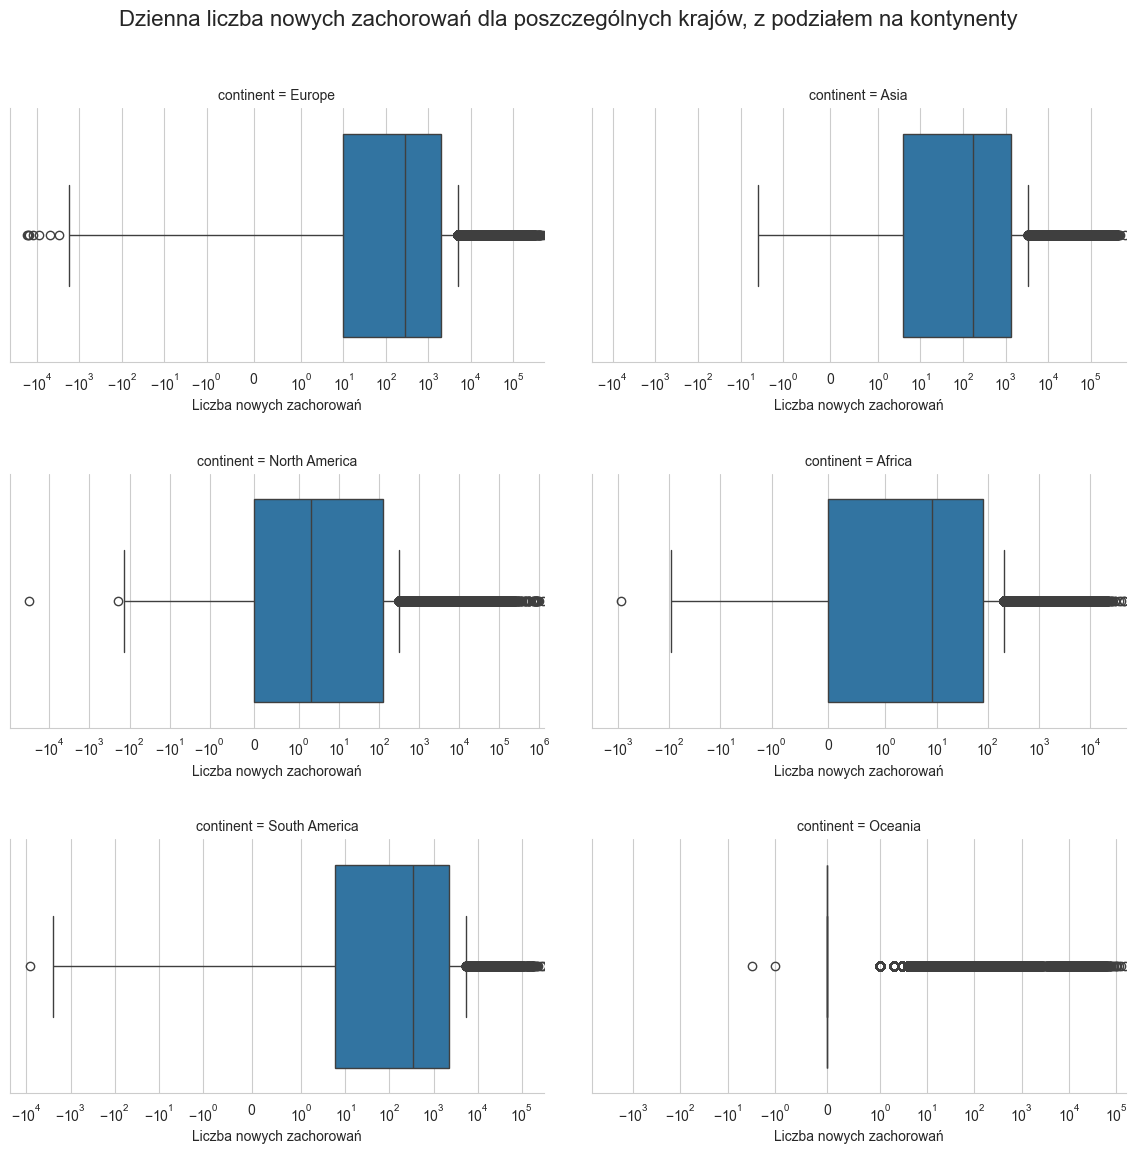

In [6]:
g = sns.FacetGrid(df_countries, col='continent', col_wrap=2, height=4, aspect=1.5, sharex=False)
g.map(sns.boxplot, 'new_confirmed')

for ax in g.axes.flatten():
    ax.set_xscale('symlog', linthresh=1)
    ax.set_xlabel('Liczba nowych zachorowań')

g.fig.suptitle(
    'Dzienna liczba nowych zachorowań dla poszczególnych krajów, z podziałem na kontynenty',
    fontsize=16, y=0.98
)

plt.tight_layout(pad=3)
plt.show()

#### **1.2.** liczby nowych śmierci,

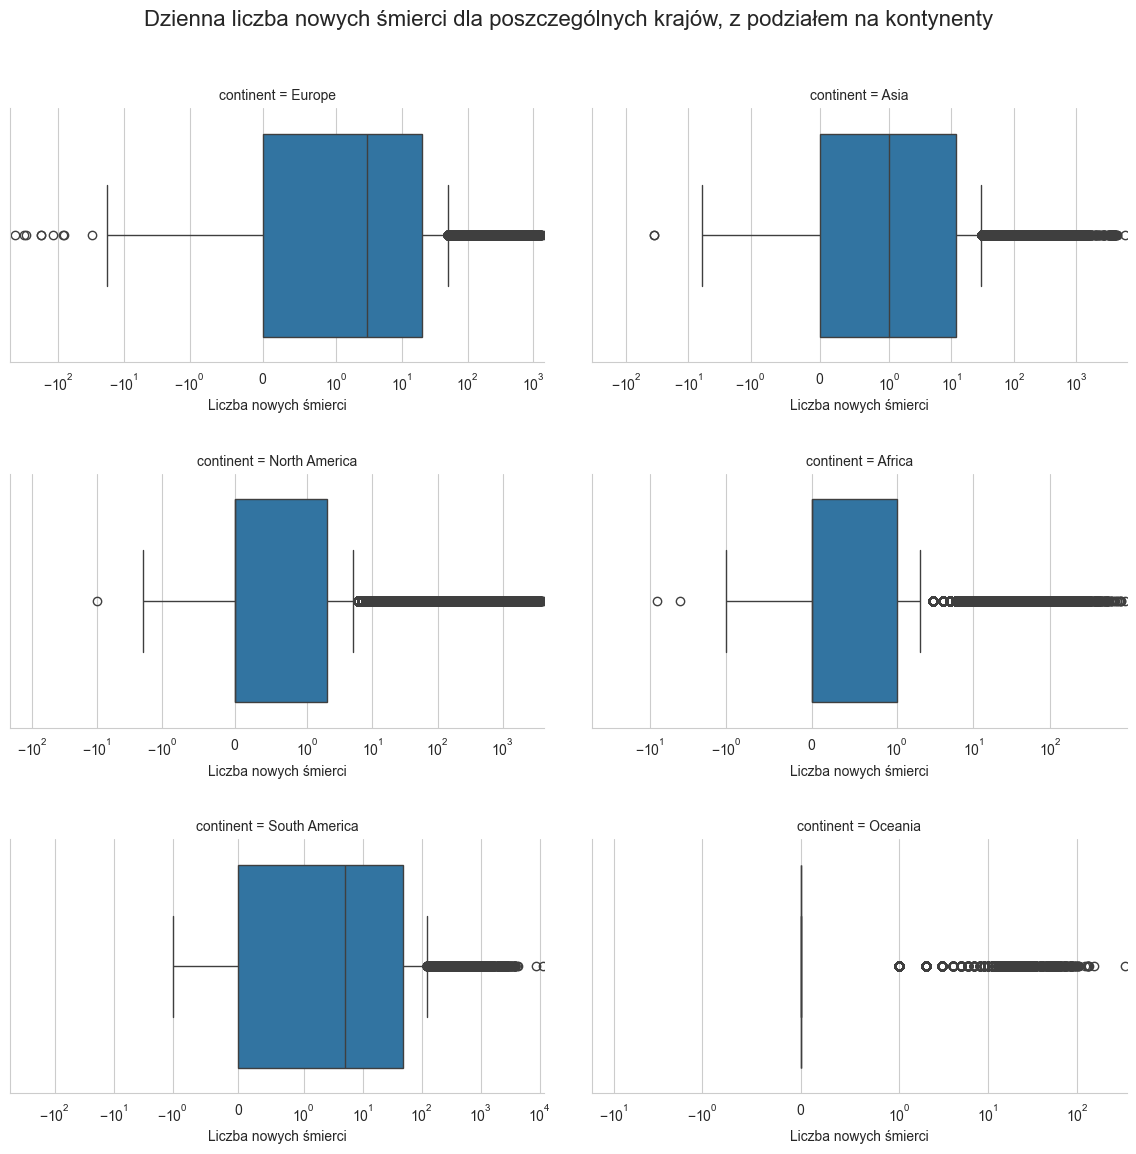

In [7]:
g = sns.FacetGrid(df_countries, col='continent', col_wrap=2, height=4, aspect=1.5, sharex=False)
g.map(sns.boxplot, 'new_deceased')

for ax in g.axes.flatten():
    ax.set_xscale('symlog', linthresh=1)
    ax.set_xlabel('Liczba nowych śmierci')

g.fig.suptitle(
    'Dzienna liczba nowych śmierci dla poszczególnych krajów, z podziałem na kontynenty',
    fontsize=16, y=0.98
)

plt.tight_layout(pad=3)
plt.show()

#### **1.3.** liczby nowych szczepień,

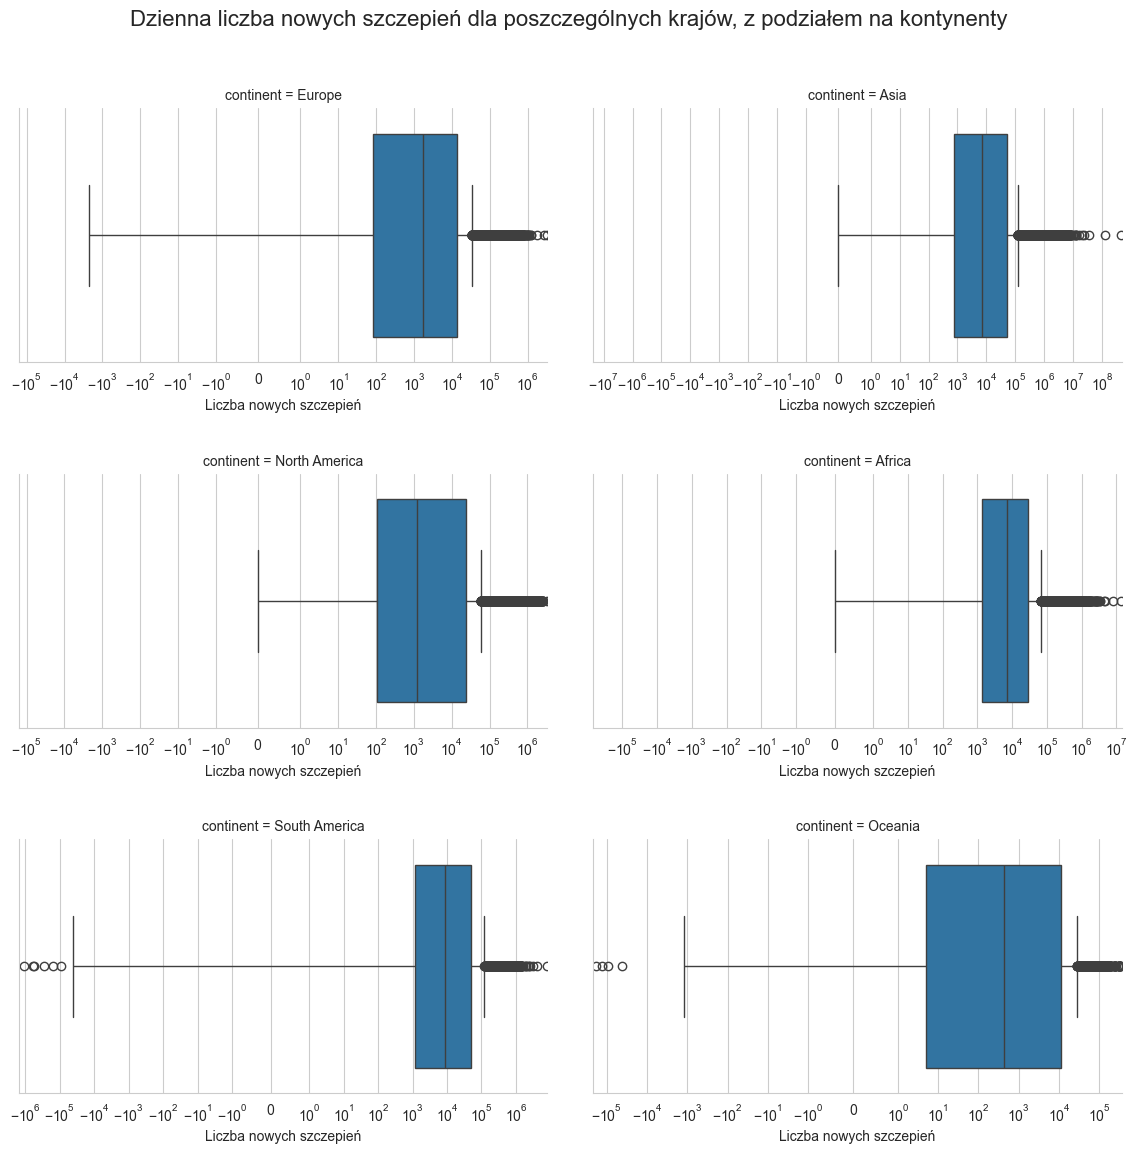

In [8]:
g = sns.FacetGrid(df_countries, col='continent', col_wrap=2, height=4, aspect=1.5, sharex=False)
g.map(sns.boxplot, 'new_persons_vaccinated')

for ax in g.axes.flatten():
    ax.set_xscale('symlog', linthresh=1)
    ax.set_xlabel('Liczba nowych szczepień')

g.fig.suptitle(
    'Dzienna liczba nowych szczepień dla poszczególnych krajów, z podziałem na kontynenty',
    fontsize=16, y=0.98
)

plt.tight_layout(pad=3)
plt.show()

#### **1.4.** populacji,

In [9]:
df_countries_yearly = df_countries.copy()

df_countries_yearly['date'] = pd.to_datetime(
    df_countries_yearly['date']
)

df_countries_yearly['year'] = df_countries_yearly['date'].dt.year

df_normalized_countries_yearly = df_countries_yearly.drop_duplicates(
    subset=['country_name', 'year']
)

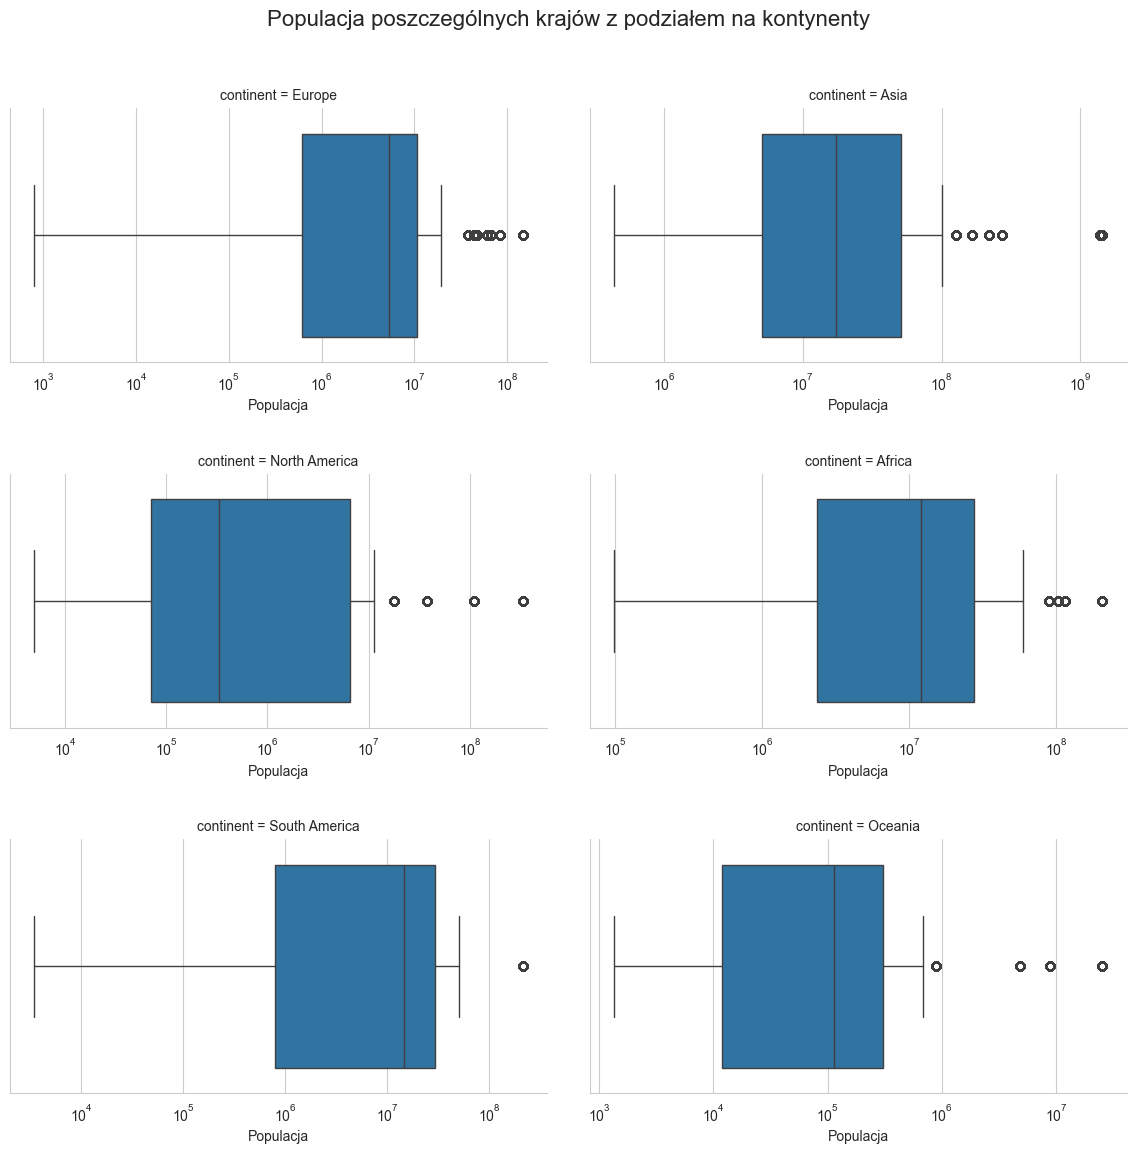

In [10]:
g = sns.FacetGrid(df_countries_yearly, col='continent', col_wrap=2, height=4, aspect=1.5, sharex=False)
g.map(sns.boxplot, 'population')

for ax in g.axes.flatten():
    ax.set_xscale('log')
    ax.set_xlabel('Populacja')

g.fig.suptitle(
    'Populacja poszczególnych krajów z podziałem na kontynenty',
    fontsize=16, y=0.98
)

plt.tight_layout(pad=3)
plt.show()

#### **1.5.** PKB,

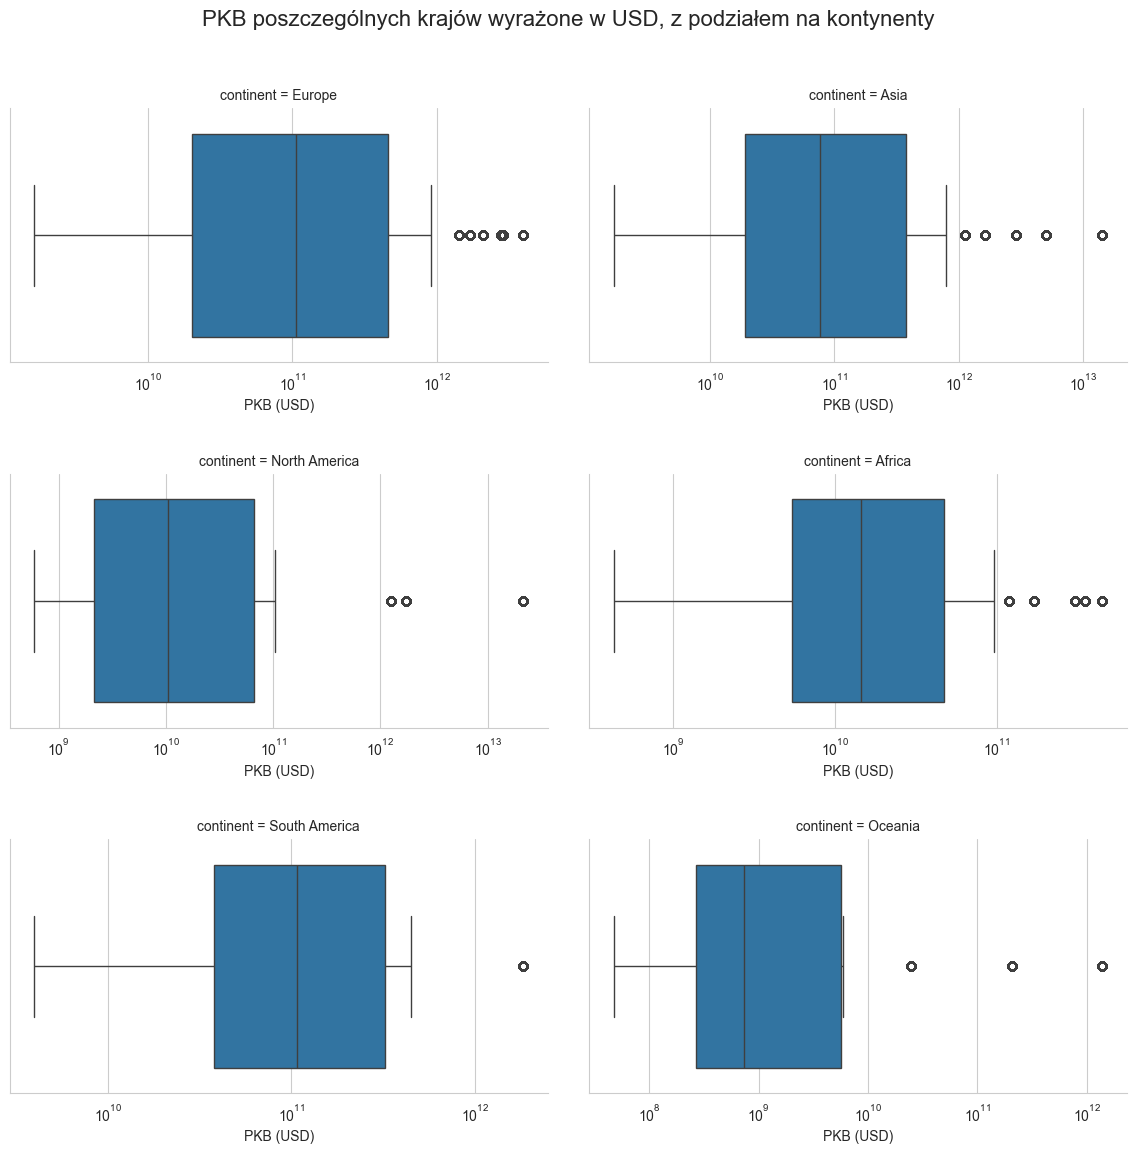

In [11]:
g = sns.FacetGrid(df_countries_yearly, col='continent', col_wrap=2, height=4, aspect=1.5, sharex=False)
g.map(sns.boxplot, 'gdp_usd')

for ax in g.axes.flatten():
    ax.set_xscale('log')
    ax.set_xlabel('PKB (USD)')

g.fig.suptitle(
    'PKB poszczególnych krajów wyrażone w USD, z podziałem na kontynenty',
    fontsize=16, y=0.98
)

plt.tight_layout(pad=3)
plt.show()

#### **1.6.** 4 innych różnych informacji, które uznasz za istotne.

##### 1. Miesięczna generacja i zapotrzebowanie energii elektrycznej w TWh dla poszczególnych krajów.

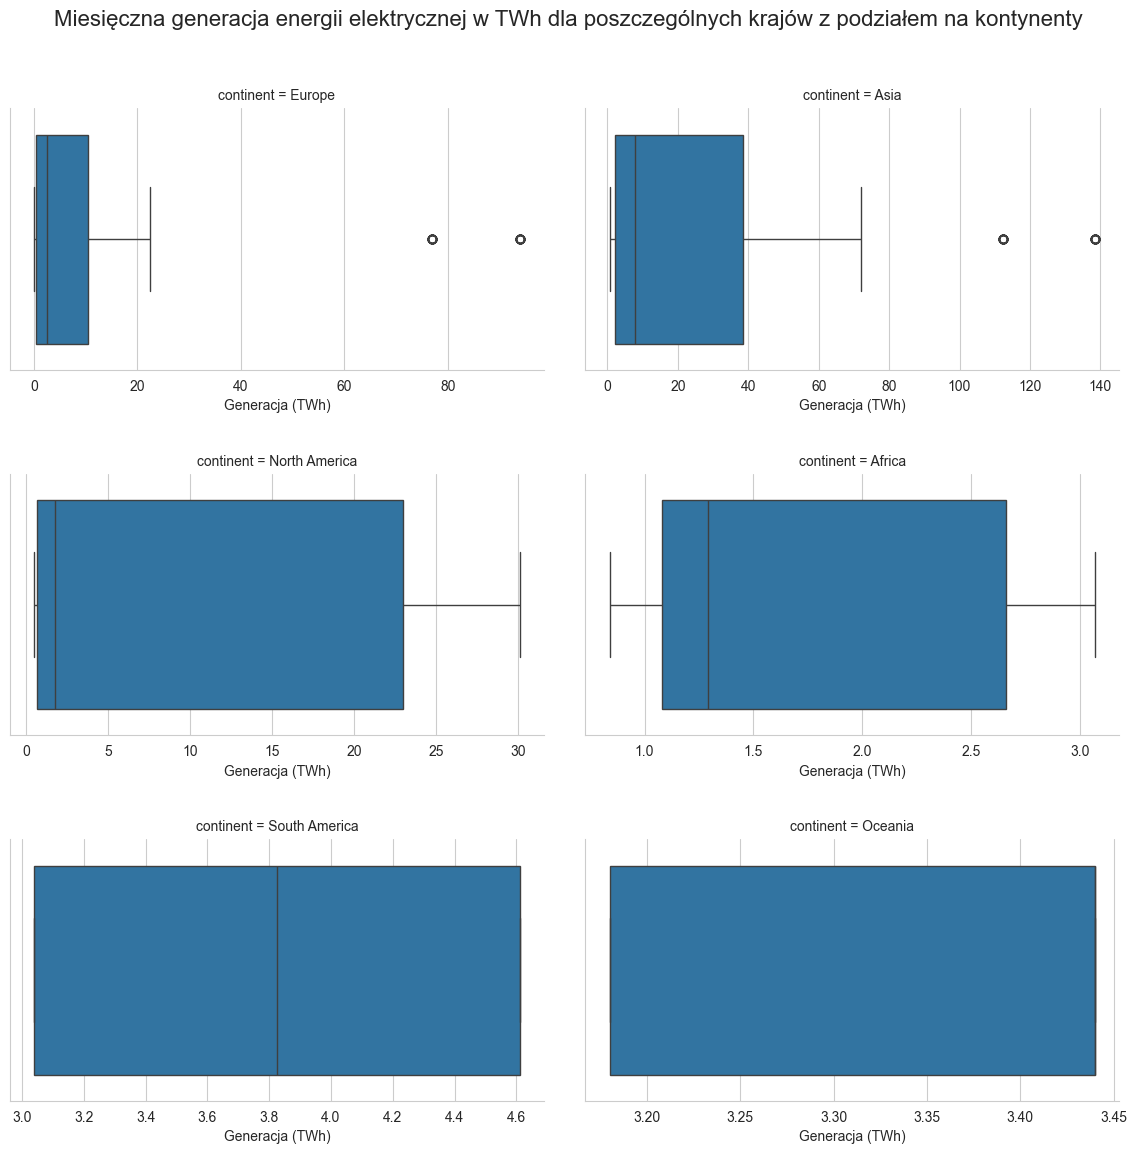

In [12]:
g = sns.FacetGrid(df_countries, col='continent', col_wrap=2, height=4, aspect=1.5, sharex=False)
g.map(sns.boxplot, 'country_electricity_generation_twh_monthly')

for ax in g.axes.flatten():
    ax.set_xlabel('Generacja (TWh)')

g.fig.suptitle(
    'Miesięczna generacja energii elektrycznej w TWh dla poszczególnych krajów z podziałem na kontynenty',
    fontsize=16, y=0.98
)

plt.tight_layout(pad=3)
plt.show()

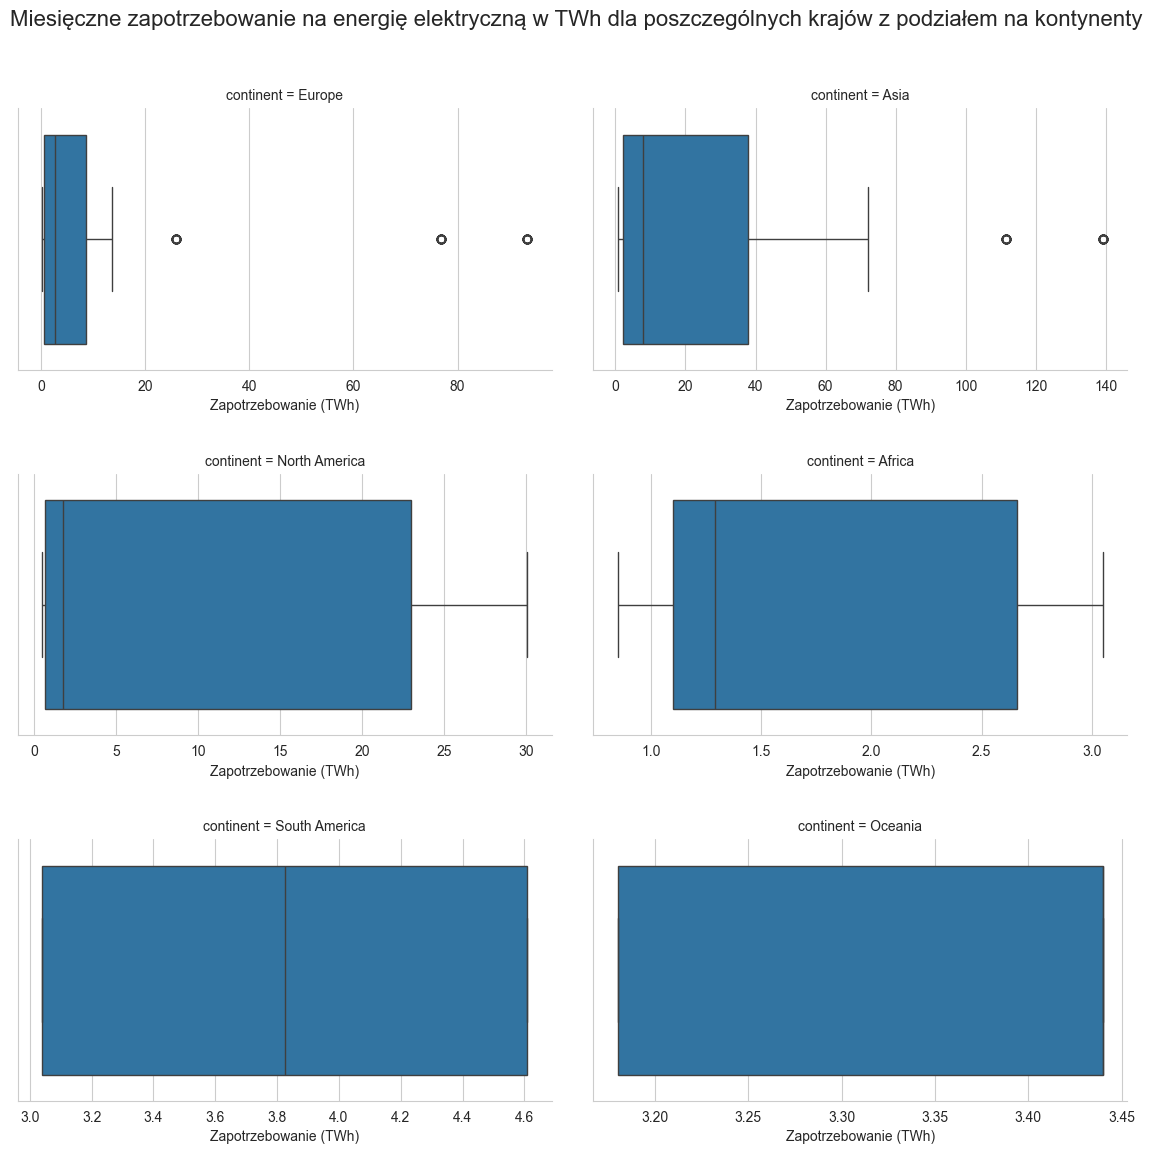

In [13]:
g = sns.FacetGrid(df_countries, col='continent', col_wrap=2, height=4, aspect=1.5, sharex=False)
g.map(sns.boxplot, 'country_electricity_demand_twh_monthly')

for ax in g.axes.flatten():
    ax.set_xlabel('Zapotrzebowanie (TWh)')

g.fig.suptitle(
    'Miesięczne zapotrzebowanie na energię elektryczną w TWh dla poszczególnych krajów z podziałem na kontynenty',
    fontsize=16, y=0.98
)

plt.tight_layout(pad=3)
plt.show()

##### 2. Dzienny indeks jakości powietrza (AQI) dla poszczególnych hrabstw w USA.

In [14]:
df_us_counties = df_combined.query("iso_3166_1_alpha_2 == 'US' & aggregation_level == 2")

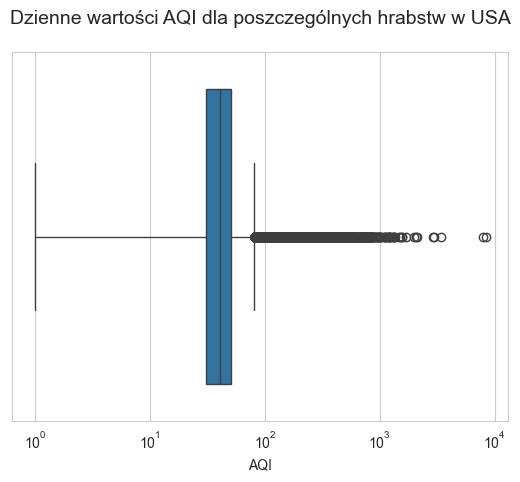

In [15]:
fig, ax = plt.subplots()

sns.boxplot(df_us_counties, x='aqi_daily', ax=ax)

ax.set_xscale('log')

ax.set_xlabel('AQI')
ax.set_title('Dzienne wartości AQI dla poszczególnych hrabstw w USA', fontsize=14, pad=20)

plt.show()

##### 3. Średnia kwota wydana na opiekę zdrowotną na osobę w USD w danym kraju.

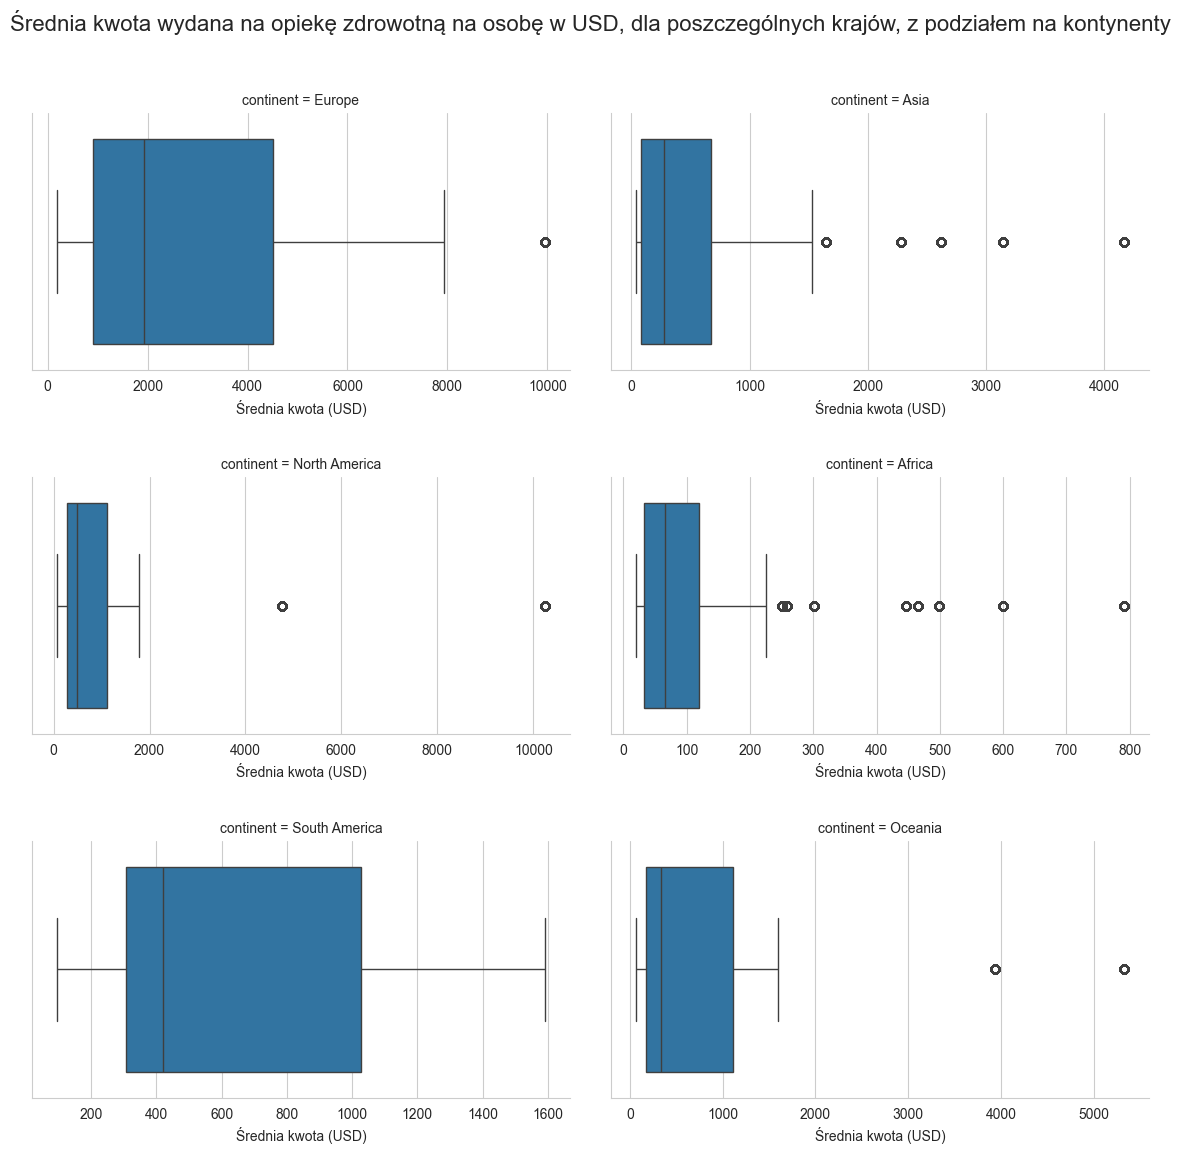

In [16]:
g = sns.FacetGrid(df_countries_yearly, col='continent', col_wrap=2, height=4, aspect=1.5, sharex=False)
g.map(sns.boxplot, 'health_expenditure_usd')

for ax in g.axes.flatten():
    ax.set_xlabel('Średnia kwota (USD)')

g.fig.suptitle(
    'Średnia kwota wydana na opiekę zdrowotną na osobę w USD, dla poszczególnych krajów, z podziałem na kontynenty',
    fontsize=16, y=0.98
)

plt.tight_layout(pad=3)
plt.show()

##### 4. Trendy wyszukiwań:

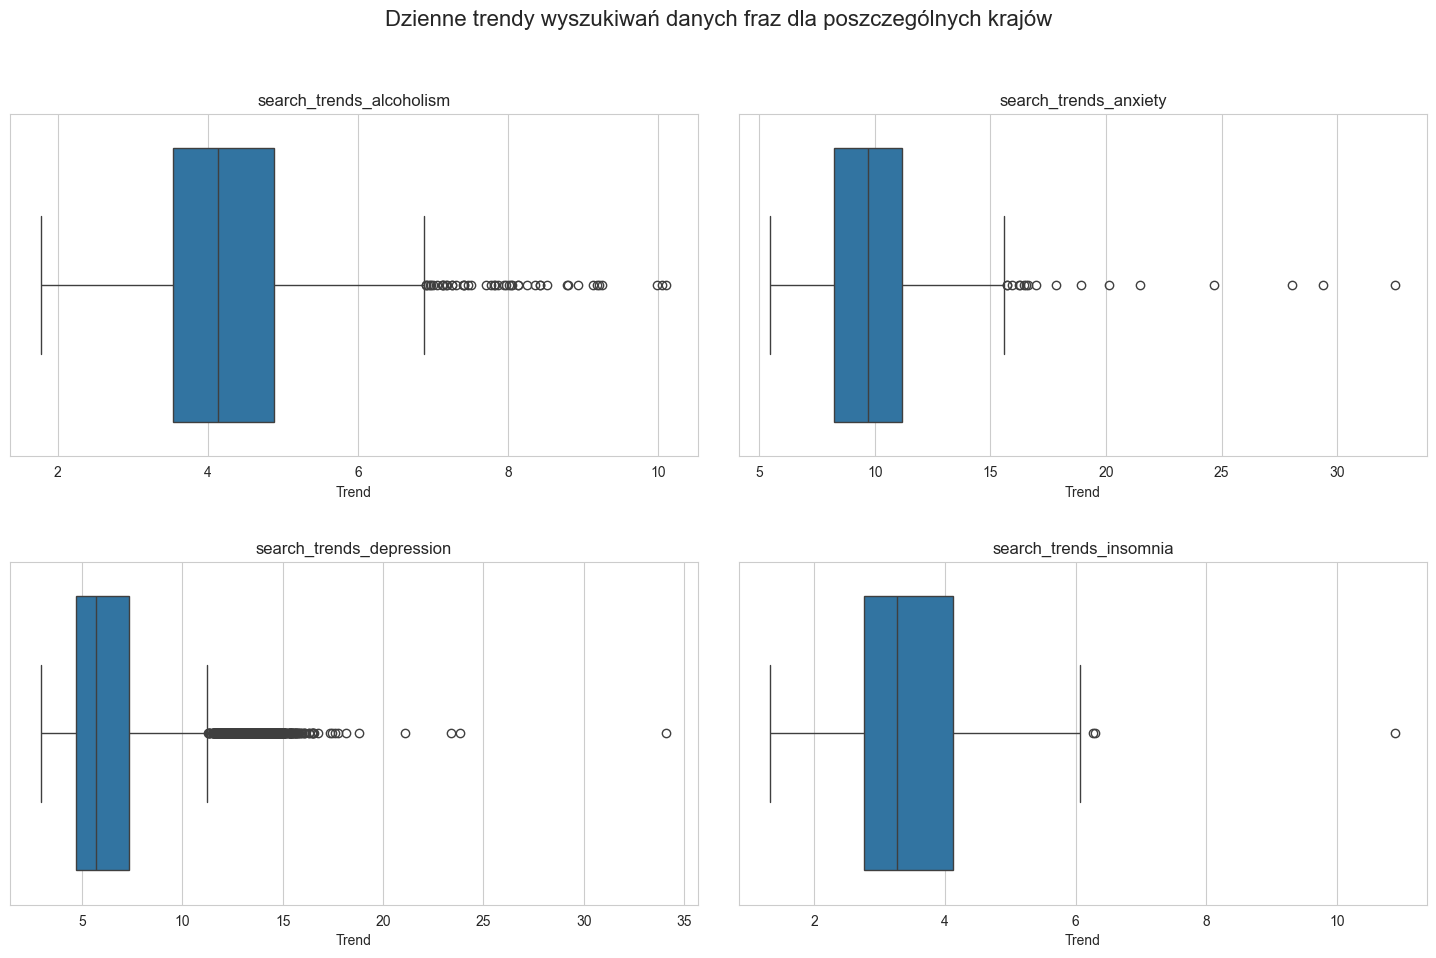

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

search_trends_columns = [
    'search_trends_alcoholism',
    'search_trends_anxiety',
    'search_trends_depression',
    'search_trends_insomnia'
]

for i, col in enumerate(search_trends_columns):
    ax = axes.flatten()[i]
    sns.boxplot(df_countries, x=col, ax=ax)
    ax.set_xlabel('Trend')
    ax.set_title(col)

fig.suptitle(
    'Dzienne trendy wyszukiwań danych fraz dla poszczególnych krajów',
    fontsize=16, y=0.98
)

plt.tight_layout(pad=3)
plt.show()

## Część 2
**Misja dodatkowa — Outliery**

***Outliery**, czyli wartości odstające można zidentyfikować i usunąć lub zmienić na bardziej odpowiednie przed przeprowadzeniem transformacji danych. Istnieje kilka technik do wykrywania wartości odstających, m.in.:*

***Metoda Z-Score**
Metoda statystyczna, która mierzy, jak wiele odchyleń standardowych wartość jest oddalona od średniej. Wartości z wysokim Z-Score (np. powyżej 2 lub 3) mogą być uznane za wartości odstające, a następnie usunięte.*

***Metoda IQR (ang. InterQuartile Range)**
Technika oparta na kwartylach, w której oblicza się zakres międzykwartylowy (Q3 - Q1) i wartości odstające są określane jako wartości leżące poza granicami 1,5 IQR poniżej Q1 lub powyżej Q3.*

#### Usuń wartości odstające dla co najmniej 2 informacji z części 1 poziomu 2. W tym celu użyj dwóch różnych metod obliczania outlierów. Uzasadnij swój wybór. Przeanalizuj otrzymane wyniki.

In [18]:
def detect_outliers_iqr(x):
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return (x < lower) | (x > upper)


def detect_outliers_z_score(x, stds_num=2):
    mean = x.mean()
    lower = mean - (stds_num * x.std())
    upper = mean + (stds_num * x.std())

    return (x < lower) | (x > upper)


def detect_outliers_modified_z_score(x):
    median = x.median()
    mad = (np.abs(x - median)).median()
    z = 0.6745 * (x - median) / mad

    return z.abs() > 3.5

##### 1. Dzienny indeks jakości powietrza (AQI) dla poszczególnych hrabstw w USA.

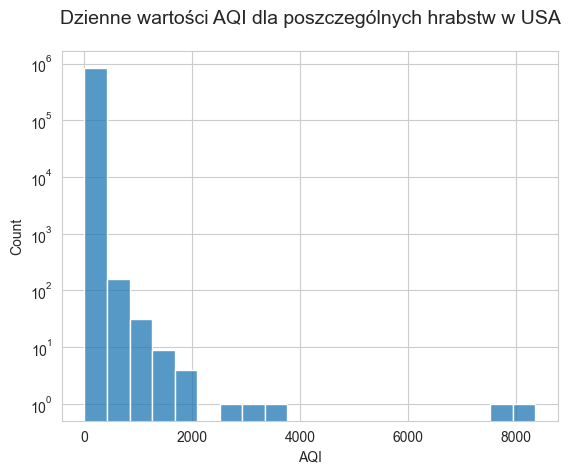

In [19]:
fig, ax = plt.subplots()

sns.histplot(df_us_counties, x='aqi_daily', ax=ax, bins=20)

ax.set_yscale('log')
ax.set_xlabel('AQI')
ax.set_title('Dzienne wartości AQI dla poszczególnych hrabstw w USA', fontsize=14, pad=20)

plt.show()

Ze względu na skośność rozkładu danych, wartości odstające zostaną usunięte przy użyciu metody IQR, która nie zakłada normalności rozkładu.

In [20]:
initial_aqi_values_count = df_combined['aqi_daily'].notna().sum()

for group, group_data in df_combined.groupby('subregion2_name'):
    outliers = detect_outliers_iqr(group_data['aqi_daily'])
    df_combined.loc[group_data.index[outliers], 'aqi_daily'] = None

aqi_values_count_after_outliers_removal = df_combined['aqi_daily'].notna().sum()

percent_of_aqi_outliers = (
    (initial_aqi_values_count - aqi_values_count_after_outliers_removal) /
    initial_aqi_values_count * 100
)

In [21]:
print(f'Całkowity procent usuniętych wartości AQI: {percent_of_aqi_outliers}')

Całkowity procent usuniętych wartości AQI: 3.4125118684410856


In [22]:
df_us_counties = df_combined.query("iso_3166_1_alpha_2 == 'US' & aggregation_level == 2")

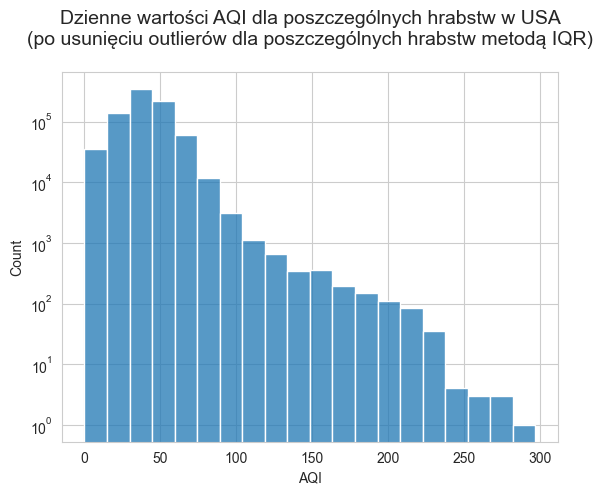

In [23]:
fig, ax = plt.subplots()

sns.histplot(df_us_counties, x='aqi_daily', ax=ax, bins=20)

ax.set_yscale('log')
ax.set_xlabel('AQI')
ax.set_title(
    'Dzienne wartości AQI dla poszczególnych hrabstw w USA\n'
    '(po usunięciu outlierów dla poszczególnych hrabstw metodą IQR)',
    fontsize=14, pad=20
)

plt.show()

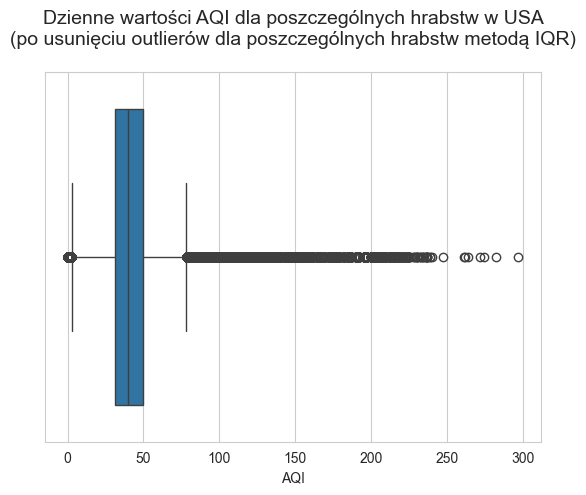

In [24]:
_, ax = plt.subplots()

sns.boxplot(df_us_counties, x='aqi_daily', ax=ax)

ax.set_xlabel('AQI')
ax.set_title(
    'Dzienne wartości AQI dla poszczególnych hrabstw w USA\n'
    '(po usunięciu outlierów dla poszczególnych hrabstw metodą IQR)',
    fontsize=14, pad=20
)

plt.show()

##### 2. Trendy wyszukiwań.

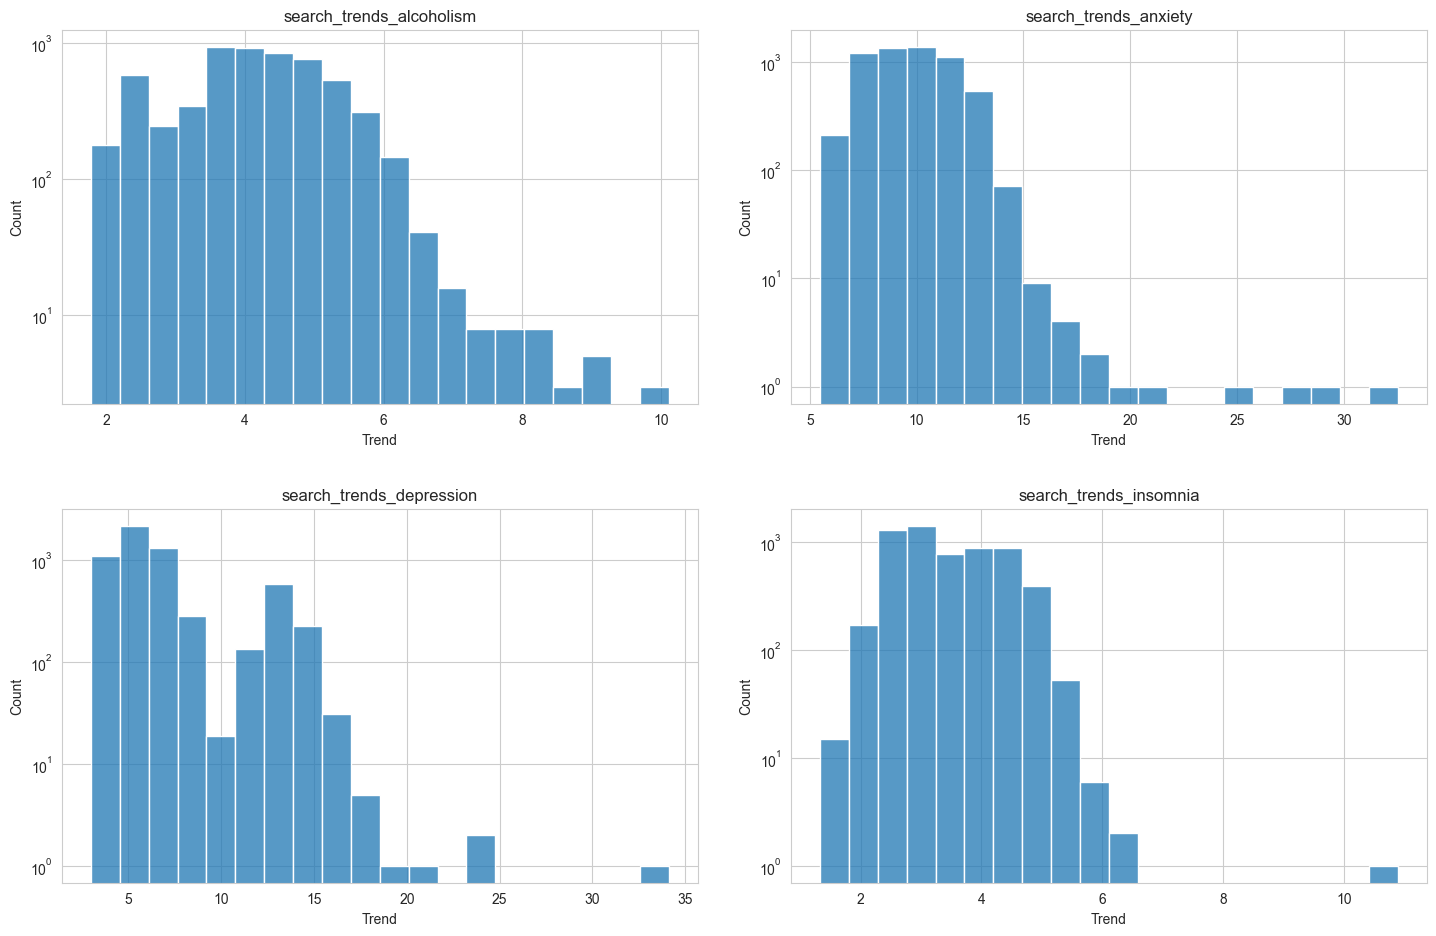

In [25]:
_, axes = plt.subplots(2, 2, figsize=(15, 10))

search_trends_columns = [
    'search_trends_alcoholism',
    'search_trends_anxiety',
    'search_trends_depression',
    'search_trends_insomnia'
]

for i, col in enumerate(search_trends_columns):
    ax = axes.flatten()[i]
    sns.histplot(df_countries, x=col, ax=ax, bins=20)
    ax.set_yscale('log')
    ax.set_xlabel('Trend')
    ax.set_title(col)

fig.suptitle(
    'Dzienne trendy wyszukiwań danych fraz dla poszczególnych krajów',
    fontsize=16, y=0.98
)

plt.tight_layout(pad=3)
plt.show()

Ze względu na skośność rozkładu danych, wartości odstające zostaną usunięte przy użyciu zmodyfikowanej metody z-score, która nie zakłada normalności rozkładu.

In [26]:
columns = [
    'search_trends_alcoholism', 'search_trends_anxiety',
    'search_trends_depression', 'search_trends_insomnia'
]

percentages_of_search_trends_outliers = {}

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="Mean of empty slice"
    )
    for col in columns:
        initial_values_count = df_combined[col].notna().sum()

        for group, group_data in df_combined.groupby(['aggregation_level', 'country_name']):
            outliers = detect_outliers_modified_z_score(group_data[col])
            df_combined.loc[group_data.index[outliers], col] = None

        values_count_after_outliers_removal = df_combined[col].notna().sum()
        percentages_of_search_trends_outliers[col] = (
            (initial_values_count - values_count_after_outliers_removal) /
            initial_values_count * 100
        )

In [27]:
for search_trend, percentage in percentages_of_search_trends_outliers.items():
    print(f'Całkowity procent usuniętych wartości {search_trend}: {percentage}')

Całkowity procent usuniętych wartości search_trends_alcoholism: 1.3059047514313404
Całkowity procent usuniętych wartości search_trends_anxiety: 0.8400137425561154
Całkowity procent usuniętych wartości search_trends_depression: 0.9923222145195972
Całkowity procent usuniętych wartości search_trends_insomnia: 0.7863908110700035


In [28]:
df_countries = df_combined.query("aggregation_level == 0")

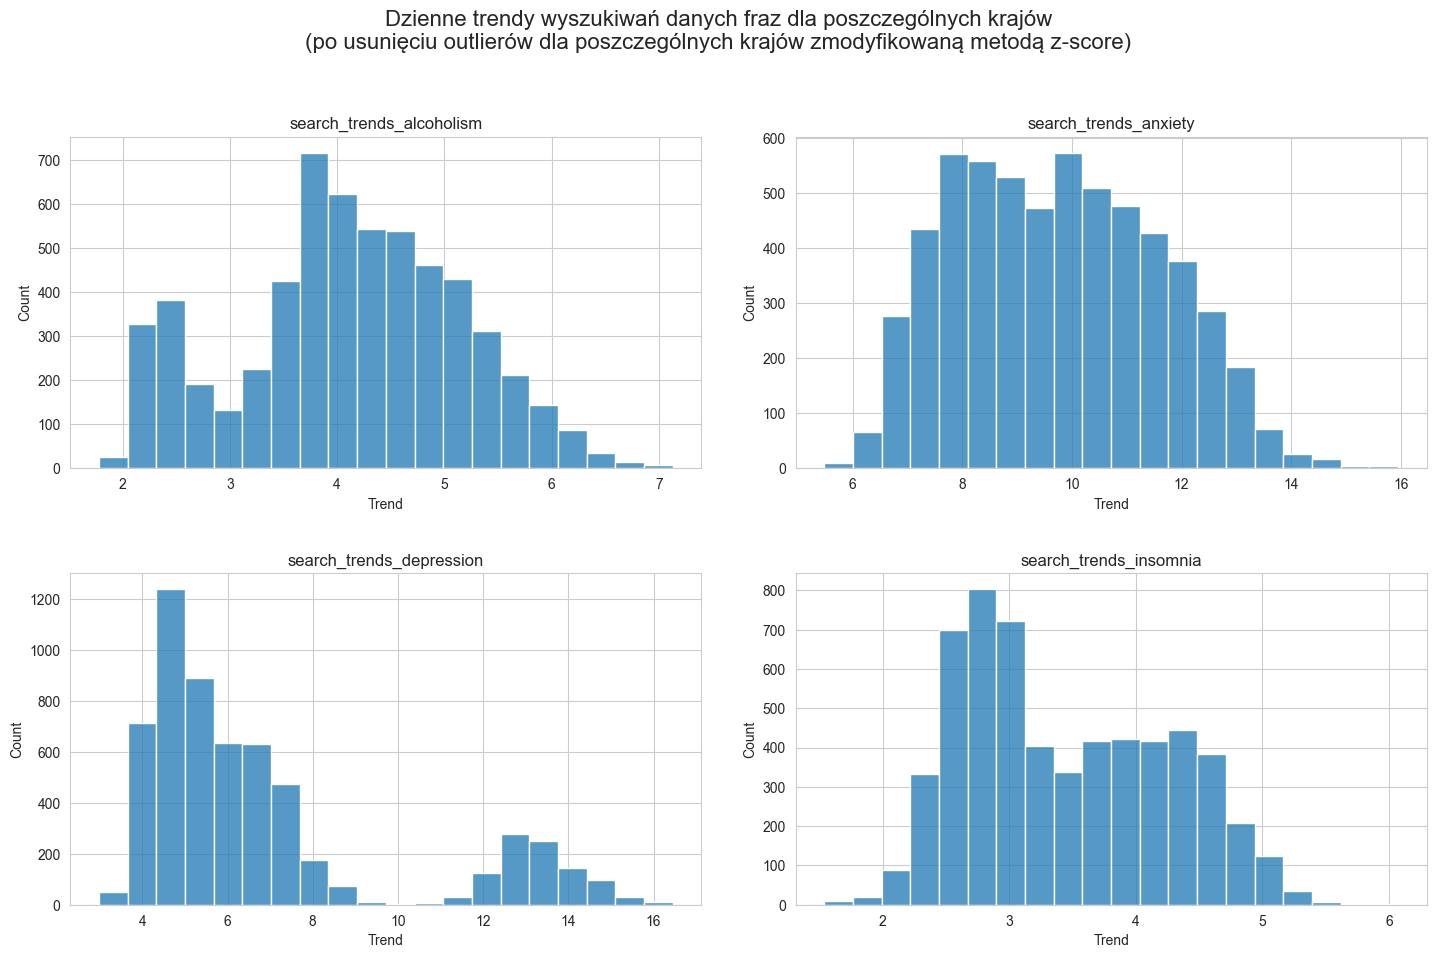

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

search_trends_columns = [
    'search_trends_alcoholism',
    'search_trends_anxiety',
    'search_trends_depression',
    'search_trends_insomnia'
]

for i, col in enumerate(search_trends_columns):
    ax = axes.flatten()[i]
    sns.histplot(df_countries, x=col, ax=ax, bins=20)
    ax.set_xlabel('Trend')
    ax.set_title(col)

fig.suptitle(
    'Dzienne trendy wyszukiwań danych fraz dla poszczególnych krajów\n'
    '(po usunięciu outlierów dla poszczególnych krajów zmodyfikowaną metodą z-score)',
    fontsize=16, y=0.98
)

plt.tight_layout(pad=3)
plt.show()

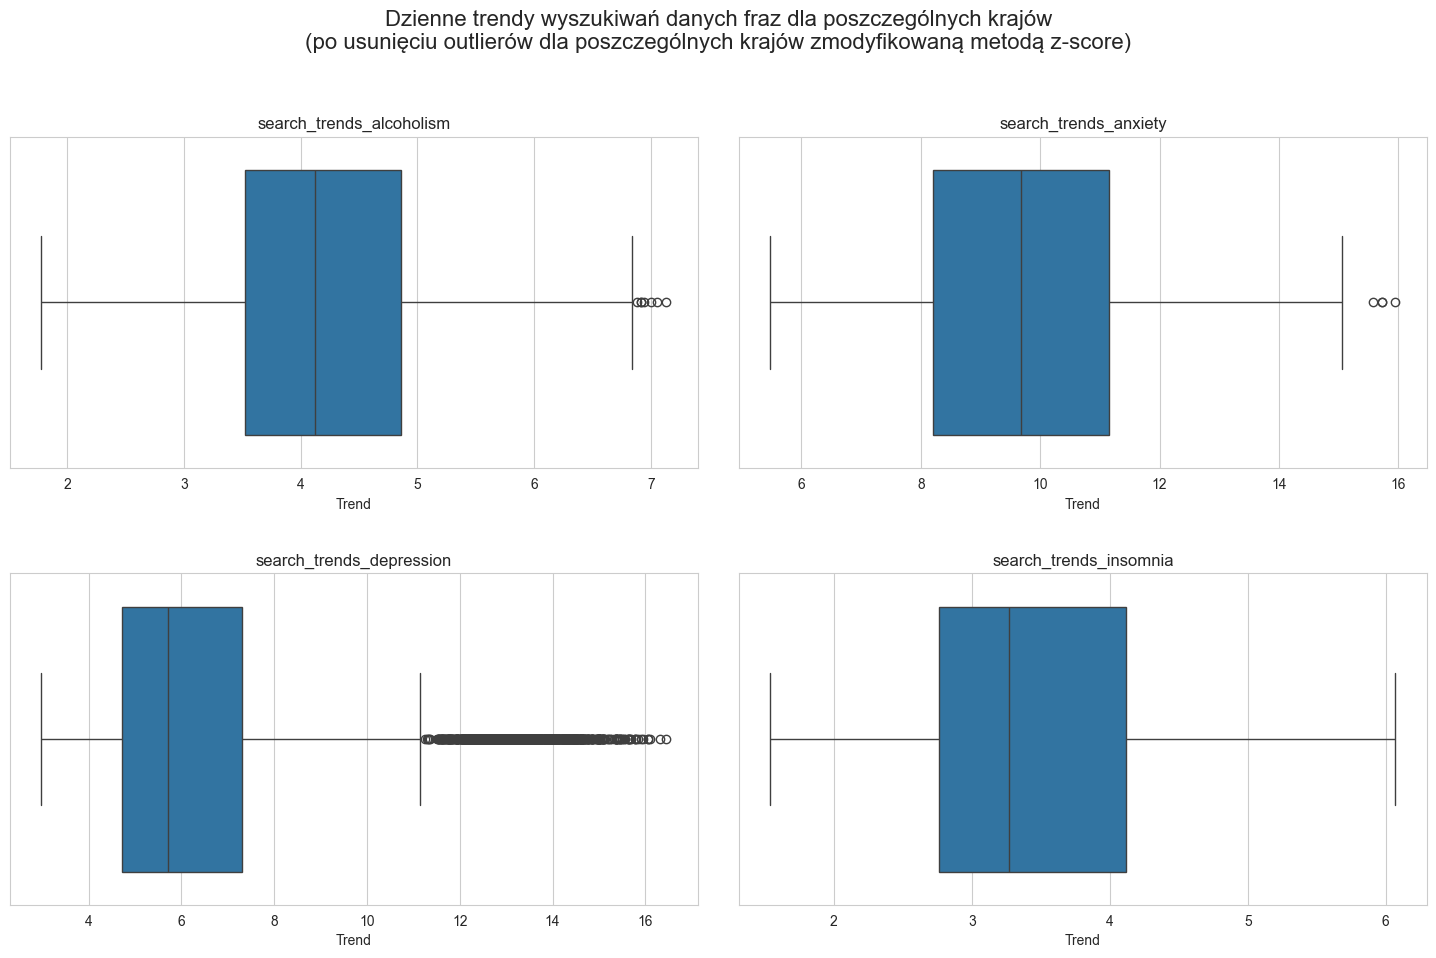

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

search_trends_columns = [
    'search_trends_alcoholism',
    'search_trends_anxiety',
    'search_trends_depression',
    'search_trends_insomnia',
]

for i, col in enumerate(search_trends_columns):
    ax = axes.flatten()[i]
    sns.boxplot(df_countries, x=col, ax=ax)
    ax.set_xlabel('Trend')
    ax.set_title(col)

fig.suptitle(
    'Dzienne trendy wyszukiwań danych fraz dla poszczególnych krajów\n'
    '(po usunięciu outlierów dla poszczególnych krajów zmodyfikowaną metodą z-score)',
    fontsize=16, y=0.98
)

plt.tight_layout(pad=3)
plt.show()

## Część 3

***Obliczenia statystyczne** (m.in. średnia, mediana, moda, odchylenie standardowe) pozwalają na zrozumienie rozkładu danych oraz na identyfikację ewentualnych anomalii lub nietypowych wartości.*

Wykonaj następujące obliczenia:

#### **3.1.** średnia liczba nowych zachorowań, śmierci i szczepień dla co najmniej 10 wybranych krajów w wybranym miesiącu,

In [31]:
countries = [
    'Poland', 'India', 'France', 'Germany', 'Brazil',
    'South Korea', 'Japan', 'Italy', 'United Kingdom', 'Russia'
]
start_date, end_date = '2021-11-01', '2021-11-30'

df_filtered_countries = df_countries.query(
    'country_name in @countries'
)
df_filtered_countries_dates = df_filtered_countries.query(
    'date >= @start_date and date <= @end_date'
)

In [32]:
df_mean = df_filtered_countries_dates.groupby('country_name')[
    ['new_confirmed', 'new_deceased', 'new_persons_vaccinated']
].agg('mean')

df_mean.columns = [col + '_mean' for col in df_mean.columns]

df_mean

,new_confirmed_mean,new_deceased_mean,new_persons_vaccinated_mean
country_name,,,
Brazil,"9,453.47",228.57,"140,621.07"
France,"16,954.23",49.20,"21,537.07"
Germany,"46,150.40",365.97,"63,459.77"
India,"10,343.47",361.47,"1,850,382.23"
Italy,"8,525.67",57.60,"18,651.57"
Japan,145.83,3.07,"39,974.50"
Poland,"17,953.80",237.80,"20,884.83"
Russia,"37,184.20","1,224.20","417,580.48"
South Korea,"2,987.93",27.70,"46,426.03"


#### **3.2.** średnia zmiana liczby zachorowań, śmierci i szczepień dla co najmniej 10 wybranych krajów w wybranym miesiącu,

In [33]:
df_mean_change = df_filtered_countries_dates.assign(
    new_confirmed_change=lambda x: x.groupby('country_name')['new_confirmed'].diff(),
    new_deceased_change=lambda x: x.groupby('country_name')['new_deceased'].diff(),
    new_persons_vaccinated_change=lambda x: x.groupby('country_name')['new_persons_vaccinated'].diff()
).groupby('country_name')[
    ['new_confirmed_change', 'new_deceased_change', 'new_persons_vaccinated_change']
].agg('mean')

df_mean_change.columns = [col + '_mean' for col in df_mean_change.columns]

df_mean_change

,new_confirmed_change_mean,new_deceased_change_mean,new_persons_vaccinated_change_mean
country_name,,,
Brazil,202.48,7.14,"4,160.34"
France,"1,562.45",3.76,563.28
Germany,"1,710.31",6.69,"3,820.86"
India,-73.72,5.72,"22,798.62"
Italy,342.97,2.38,884.62
Japan,1.97,-0.21,"-1,351.55"
Poland,846.55,19.34,929.24
Russia,-212.79,1.66,"15,428.46"
South Korea,89.66,1.00,"-2,114.41"


#### **3.3.** mediana liczby nowych zachorowań, śmierci i szczepień dla co najmniej 10 wybranych krajów w wybranym miesiącu,

In [34]:
df_median = df_filtered_countries_dates.groupby('country_name')[
    ['new_confirmed', 'new_deceased', 'new_persons_vaccinated']
].agg('median')

df_median.columns = [col + '_median' for col in df_median.columns]

df_median

,new_confirmed_median,new_deceased_median,new_persons_vaccinated_median
country_name,,,
Brazil,"10,630.00",221.50,"128,439.50"
France,"12,549.50",47.50,"23,564.50"
Germany,"45,515.00",363.50,"59,990.00"
India,"10,395.00",336.00,"1,672,237.00"
Italy,"8,245.50",59.50,"18,245.50"
Japan,134.50,2.00,"32,440.50"
Poland,"17,570.00",258.00,"21,940.50"
Russia,"37,265.00","1,235.00","430,262.00"
South Korea,"2,762.00",26.00,"46,859.00"


#### **3.4.** odchylenie standardowe liczby nowych zachorowań, śmierci i szczepień dla co najmniej 10 wybranych krajów w wybranym miesiącu,

In [35]:
df_std = df_filtered_countries_dates.groupby('country_name')[
    ['new_confirmed', 'new_deceased', 'new_persons_vaccinated']
].agg('std')

df_std.columns = [col + '_std' for col in df_std.columns]

df_std

,new_confirmed_std,new_deceased_std,new_persons_vaccinated_std
country_name,,,
Brazil,"4,176.08",142.75,"78,755.83"
France,"12,112.70",31.05,"9,823.39"
Germany,"18,747.99",119.97,"39,751.56"
India,"1,623.02",125.82,"905,009.41"
Italy,"3,160.12",18.69,"6,348.59"
Japan,64.75,2.70,"23,641.47"
Poland,"6,527.48",184.96,"10,974.32"
Russia,"2,719.30",23.96,"196,503.57"
South Korea,902.47,11.67,"26,120.97"


#### **3.5.** minimalna, średnia i maksymalna liczba nowych zachorowań, szczepień i śmierci, a PKB co najmniej 10 wybranych krajów,

In [36]:
df_min_mean_max_gdp = df_filtered_countries.groupby('country_name')[
    ['new_confirmed', 'new_deceased', 'new_persons_vaccinated']
].agg(['min', 'mean', 'max'])

df_min_mean_max_gdp.columns = ['_'.join(col) for col in df_min_mean_max_gdp.columns]

df_min_mean_max_gdp = df_min_mean_max_gdp.merge(
    df_filtered_countries[['country_name', 'country_gdp_usd_2022']].drop_duplicates(),
    on='country_name', how='left'
)

df_min_mean_max_gdp

,country_name,new_confirmed_min,new_confirmed_mean,new_confirmed_max,new_deceased_min,new_deceased_mean,new_deceased_max,new_persons_vaccinated_min,new_persons_vaccinated_mean,new_persons_vaccinated_max,country_gdp_usd_2022
0,Brazil,-573.00,"34,965.81","298,408.00",0.00,692.82,"4,249.00","-297,467.00","299,188.73","2,157,048.00","1,951,923,942,083.32"
1,France,"-1,417.00","35,594.70","501,635.00",-18.00,132.75,897.00,1.00,"87,011.01","507,528.00","2,796,302,210,398.84"
2,Germany,0.00,"33,034.44","307,873.00",0.00,150.69,"1,296.00",57.00,"103,434.26","1,095,873.00","4,163,596,357,879.39"
3,India,-3.00,"45,102.82","414,188.00",0.00,535.21,"6,148.00","5,671.00","1,747,074.33","12,666,048.00","3,353,470,496,886.33"
4,Italy,0.00,"22,079.93","220,532.00",-31.00,178.61,993.00,1.00,"77,932.08","497,456.00","2,102,995,942,720.44"
5,Japan,0.00,"20,059.47","268,367.00",0.00,43.70,347.00,14.00,"187,040.03","1,070,803.00","4,256,410,760,723.75"
6,Poland,0.00,"6,283.02","57,659.00",0.00,119.12,954.00,0.00,"36,561.72","282,748.00","695,607,470,875.28"
7,Russia,0.00,"20,022.50","203,949.00",0.00,381.21,"1,254.00",0.00,"195,736.42","3,158,334.00","2,266,029,240,645.34"
8,South Korea,0.00,"24,584.06","621,328.00",0.00,28.03,470.00,2.00,"79,770.69","894,314.00","1,673,916,511,799.71"
9,United Kingdom,0.00,"23,864.76","275,647.00",0.00,191.52,"1,370.00","-2,263.00","85,160.80","752,308.00","3,114,042,471,144.39"


#### **3.6.** minimalna, średnia i maksymalna liczba nowych zachorowań, szczepień i śmierci, a populacja co najmniej 10 wybranych krajów.

In [37]:
df_min_mean_max_population = df_filtered_countries.groupby('country_name')[
    ['new_confirmed', 'new_deceased', 'new_persons_vaccinated']
].agg(['min', 'mean', 'max'])

df_min_mean_max_population.columns = ['_'.join(col) for col in df_min_mean_max_population.columns]

df_min_mean_max_population = df_min_mean_max_population.merge(
    df_filtered_countries[['country_name', 'country_population_2022']].drop_duplicates(),
    on='country_name', how='left'
)

df_min_mean_max_population

,country_name,new_confirmed_min,new_confirmed_mean,new_confirmed_max,new_deceased_min,new_deceased_mean,new_deceased_max,new_persons_vaccinated_min,new_persons_vaccinated_mean,new_persons_vaccinated_max,country_population_2022
0,Brazil,-573.00,"34,965.81","298,408.00",0.00,692.82,"4,249.00","-297,467.00","299,188.73","2,157,048.00","215,313,498.00"
1,France,"-1,417.00","35,594.70","501,635.00",-18.00,132.75,897.00,1.00,"87,011.01","507,528.00","64,626,628.00"
2,Germany,0.00,"33,034.44","307,873.00",0.00,150.69,"1,296.00",57.00,"103,434.26","1,095,873.00","83,369,843.00"
3,India,-3.00,"45,102.82","414,188.00",0.00,535.21,"6,148.00","5,671.00","1,747,074.33","12,666,048.00","1,417,173,173.00"
4,Italy,0.00,"22,079.93","220,532.00",-31.00,178.61,993.00,1.00,"77,932.08","497,456.00","59,037,474.00"
5,Japan,0.00,"20,059.47","268,367.00",0.00,43.70,347.00,14.00,"187,040.03","1,070,803.00","123,951,692.00"
6,Poland,0.00,"6,283.02","57,659.00",0.00,119.12,954.00,0.00,"36,561.72","282,748.00","39,857,145.00"
7,Russia,0.00,"20,022.50","203,949.00",0.00,381.21,"1,254.00",0.00,"195,736.42","3,158,334.00","144,713,314.00"
8,South Korea,0.00,"24,584.06","621,328.00",0.00,28.03,470.00,2.00,"79,770.69","894,314.00","51,815,810.00"
9,United Kingdom,0.00,"23,864.76","275,647.00",0.00,191.52,"1,370.00","-2,263.00","85,160.80","752,308.00","67,508,936.00"


#### Przygotuj wykresy w celu porównania otrzymanych wyników. Pamiętaj o ich czytelności (typ wykresu, tytuł wykresu, podpisy osi, odpowiednie zakresy osi itp.).

##### **Ad. 3.1.-3.4.**

In [38]:
df_plot_mean = df_mean.reset_index().melt(
    id_vars='country_name',
    var_name='metric',
    value_name='value'
)
df_plot_mean['type'] = 'Średnia'
df_plot_mean['metric'] = df_plot_mean['metric'].str.replace('_mean', '', regex=False)

df_plot_mean_change = df_mean_change.reset_index().melt(
    id_vars='country_name',
    var_name='metric',
    value_name='value'
)
df_plot_mean_change['type'] = 'Średnia zmiana'
df_plot_mean_change['metric'] = df_plot_mean_change['metric'].str.replace('_change_mean', '', regex=False)

df_plot_median = df_median.reset_index().melt(
    id_vars='country_name',
    var_name='metric',
    value_name='value'
)
df_plot_median['type'] = 'Mediana'
df_plot_median['metric'] = df_plot_median['metric'].str.replace('_median', '', regex=False)

df_plot_std = df_std.reset_index().melt(
    id_vars='country_name',
    var_name='metric',
    value_name='value'
)
df_plot_std['type'] = 'Odchylenie standardowe'
df_plot_std['metric'] = df_plot_std['metric'].str.replace('_std', '', regex=False)

df_plot_combined = pd.concat(
    [df_plot_mean, df_plot_mean_change, df_plot_median, df_plot_std],
    axis=0
)

metric_titles = {
    'new_confirmed': 'Liczba nowych zachorowań',
    'new_deceased': 'Liczba nowych śmierci',
    'new_persons_vaccinated': 'Liczba nowych szczepień'
}

df_plot_combined['metric'] = df_plot_combined['metric'].map(metric_titles)

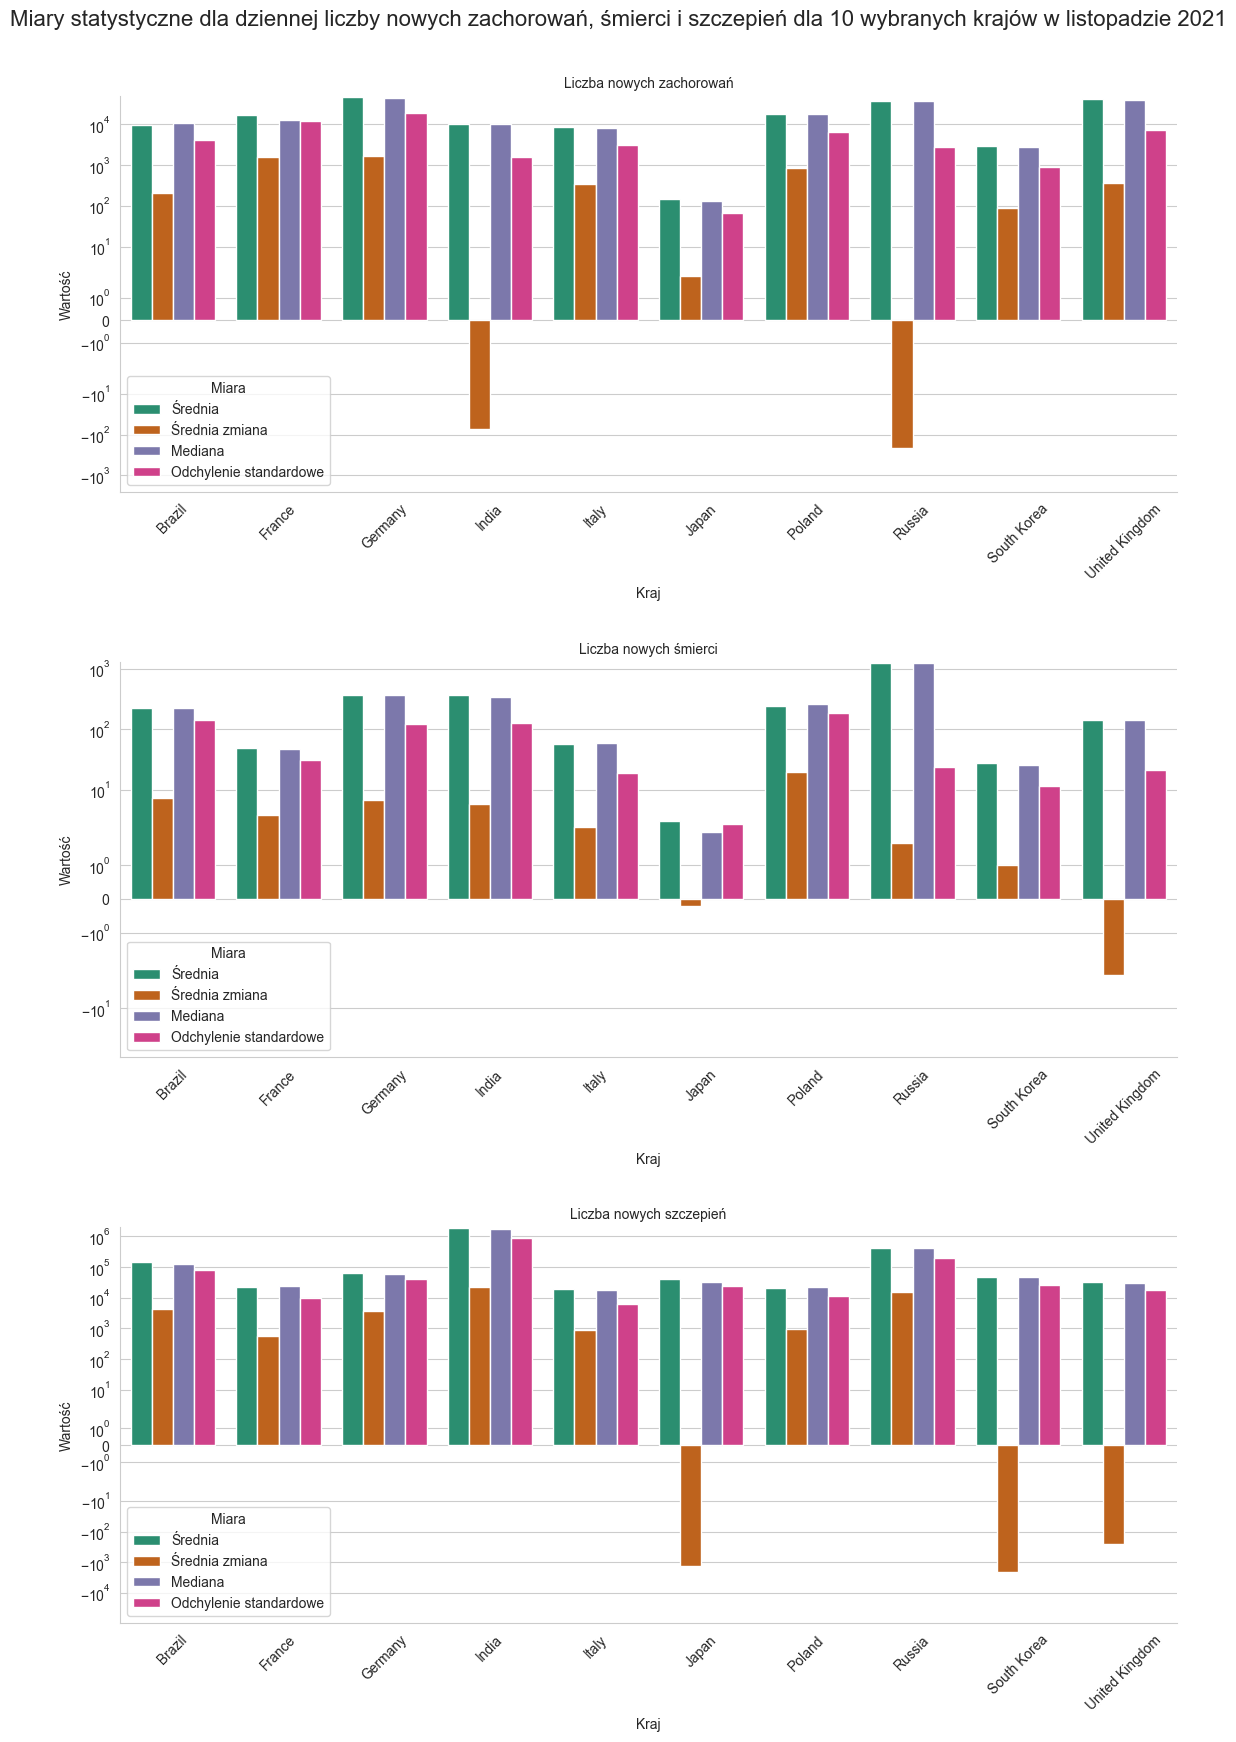

In [39]:
g = sns.FacetGrid(
    df_plot_combined,
    col='metric',
    col_wrap=1,
    sharey=False,
    sharex=False,
    height=6,
    aspect=2,
)

g.map_dataframe(
    sns.barplot,
    x='country_name',
    y='value',
    hue='type',
    palette='Dark2',
)

for ax in g.axes.flatten():
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, title='Miara')
    ax.set_yscale('symlog')
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='center')
    ax.set_xlabel('Kraj')
    ax.set_ylabel('Wartość')

g.set_titles(col_template="{col_name}")
g.fig.suptitle(
    'Miary statystyczne dla dziennej liczby nowych zachorowań, śmierci i szczepień dla 10 wybranych krajów w listopadzie 2021',
    fontsize=16, y=0.98
)

plt.tight_layout(pad=3)
plt.show()

##### **Ad. 3.5.**

In [40]:
stat_pl_labels = {
    'min': 'Minimum',
    'mean': 'Średnia',
    'max': 'Maksimum'
}

In [41]:
df_long_gdp = df_min_mean_max_gdp.melt(
    id_vars=['country_name', 'country_gdp_usd_2022'],
    value_vars=[
        col for col in df_min_mean_max_gdp.columns if col not in ['country_name', 'country_gdp_usd_2022']
    ],
    var_name='metric_stat',
    value_name='value'
)

df_long_gdp[['metric', 'stat']] = df_long_gdp['metric_stat'].str.extract(r'(new_.+?)_(min|mean|max)')

df_long_gdp['stat_pl'] = df_long_gdp['stat'].map(stat_pl_labels)

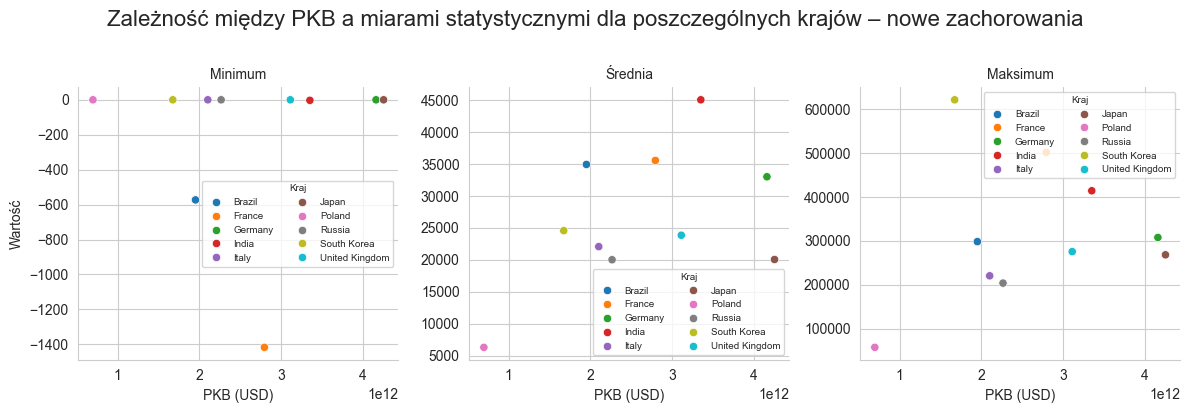

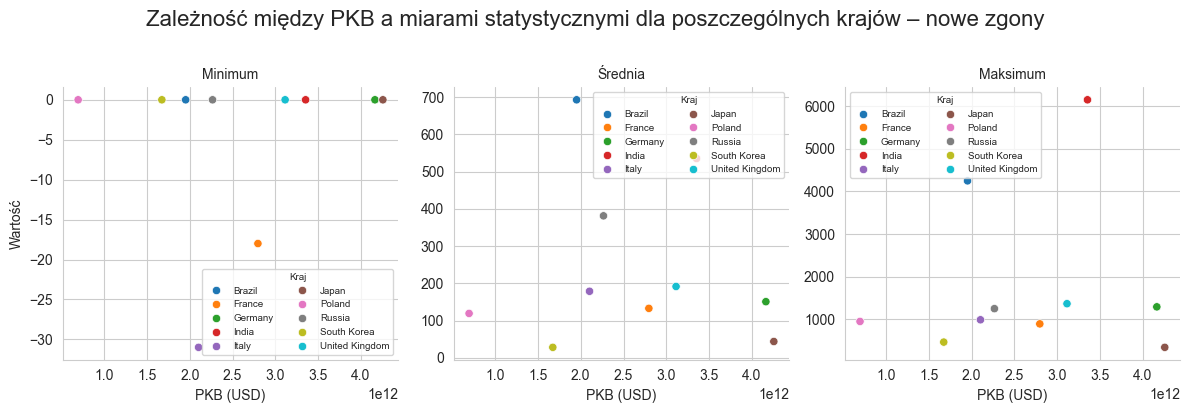

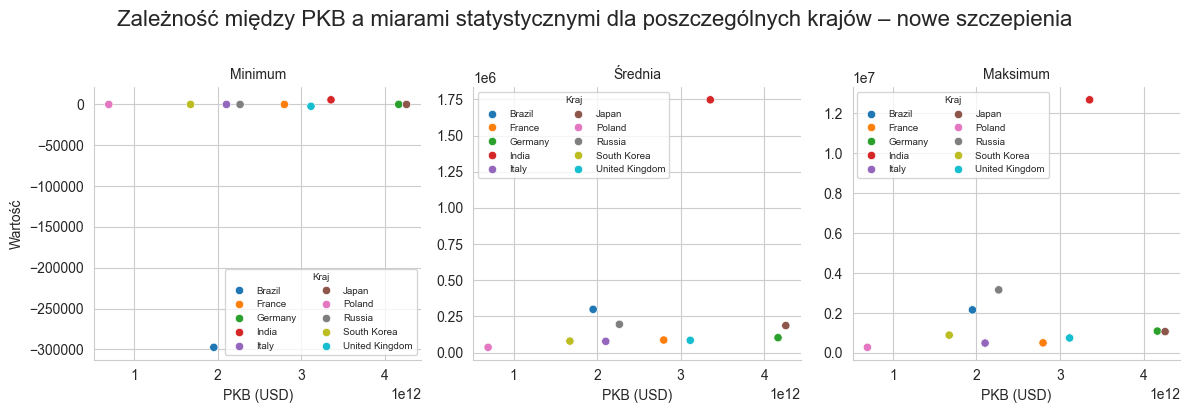

In [42]:
def plot_metric_facet(metric_name_pl, metric_filter):
    df_subset = df_long_gdp[df_long_gdp['metric'] == metric_filter]

    g = sns.FacetGrid(
        df_subset,
        col='stat_pl',
        col_wrap=3,
        height=4,
        sharex=False,
        sharey=False
    )

    g.map_dataframe(
        sns.scatterplot,
        x='country_gdp_usd_2022',
        y='value',
        hue='country_name',
        palette='tab10'
    )

    for ax in g.axes.flatten():
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, title='Kraj', fontsize=7, title_fontsize=7, ncols=2)

    g.set_axis_labels("PKB (USD)", "Wartość")
    g.set_titles(row_template="{row_name}", col_template="{col_name}")

    g.fig.suptitle(
        f"Zależność między PKB a miarami statystycznymi dla poszczególnych krajów – {metric_name_pl}",
        fontsize=16, y=1.02
    )

    plt.tight_layout()
    plt.show()


plot_metric_facet("nowe zachorowania", "new_confirmed")
plot_metric_facet("nowe zgony", "new_deceased")
plot_metric_facet("nowe szczepienia", "new_persons_vaccinated")

##### **Ad. 3.6.**

In [43]:
df_long_population = df_min_mean_max_population.melt(
    id_vars=['country_name', 'country_population_2022'],
    value_vars=[
        col for col in df_min_mean_max_population.columns if col not in ['country_name', 'country_population_2022']
    ],
    var_name='metric_stat',
    value_name='value'
)

df_long_population[['metric', 'stat']] = df_long_population['metric_stat'].str.extract(r'(new_.+?)_(min|mean|max)')

df_long_population['stat_pl'] = df_long_population['stat'].map(stat_pl_labels)

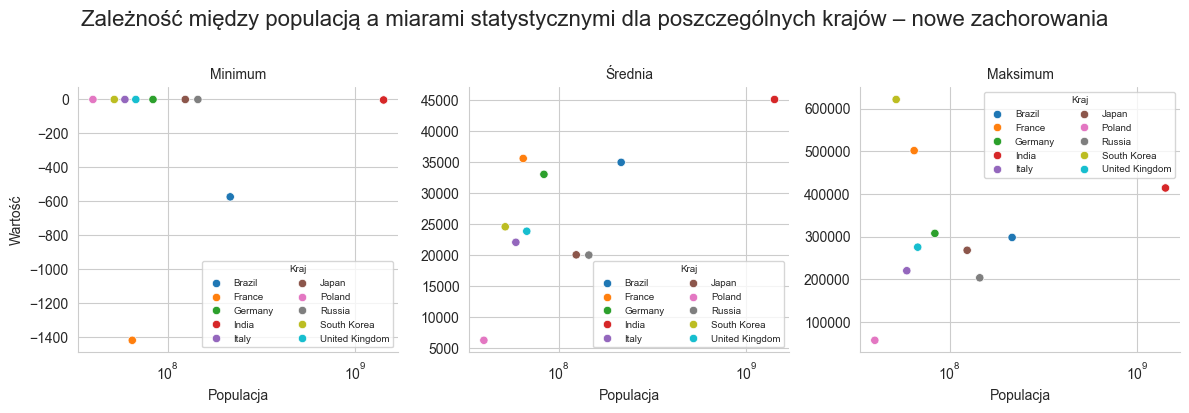

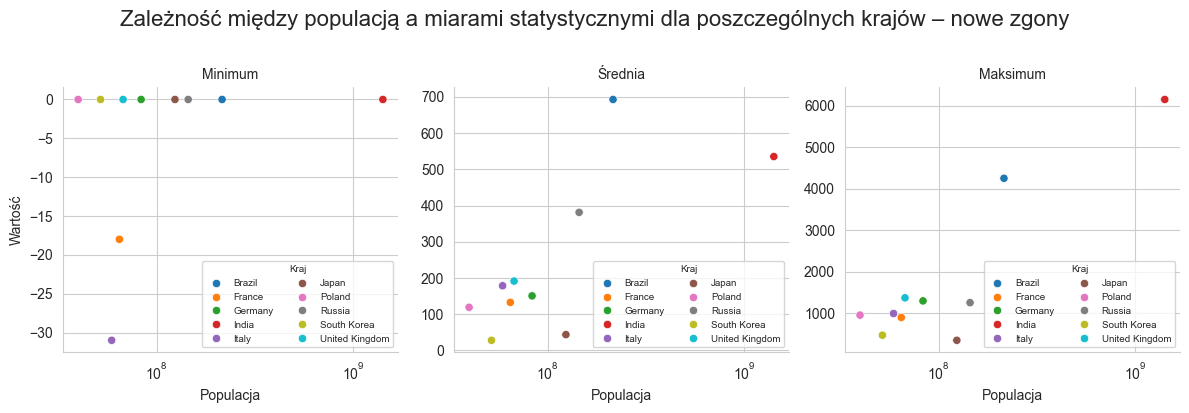

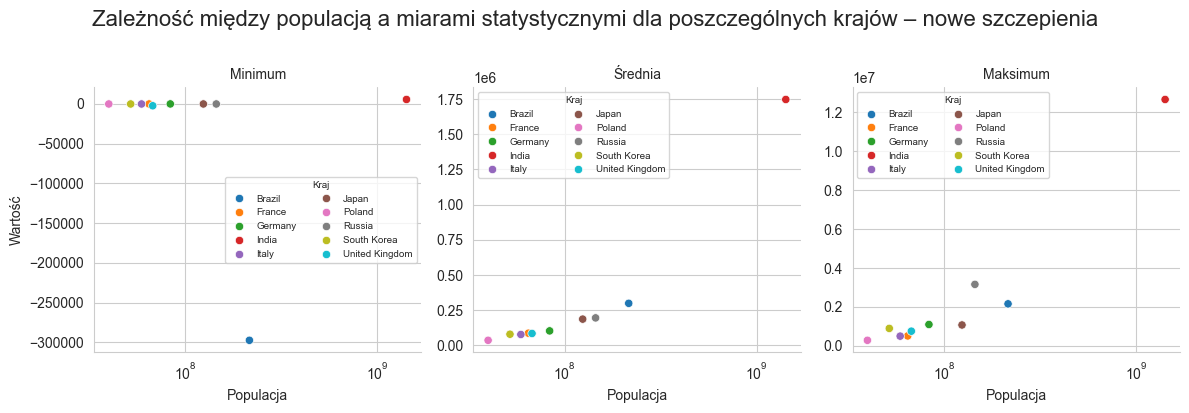

In [44]:
def plot_metric_facet(metric_name_pl, metric_filter):
    df_subset = df_long_population[df_long_population['metric'] == metric_filter]

    g = sns.FacetGrid(
        df_subset,
        col='stat_pl',
        col_wrap=3,
        height=4,
        sharex=False,
        sharey=False
    )

    g.map_dataframe(
        sns.scatterplot,
        x='country_population_2022',
        y='value',
        hue='country_name',
        palette='tab10'
    )

    for ax in g.axes.flatten():
        ax.set_xscale('log')
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, title='Kraj', fontsize=7, title_fontsize=7, ncols=2)

    g.set_axis_labels("Populacja", "Wartość")
    g.set_titles(row_template="{row_name}", col_template="{col_name}")

    g.fig.suptitle(
        f"Zależność między populacją a miarami statystycznymi dla poszczególnych krajów – {metric_name_pl}",
        fontsize=16, y=1.02
    )

    plt.tight_layout()
    plt.show()


plot_metric_facet("nowe zachorowania", "new_confirmed")
plot_metric_facet("nowe zgony", "new_deceased")
plot_metric_facet("nowe szczepienia", "new_persons_vaccinated")

## Część 4

***Normalizacja danych** polega na przeskalowaniu wartości zmiennych do określonego zakresu, np. [0, 1], co ułatwia porównanie różnych zmiennych między sobą.*

Wykonaj normalizację dla następujących przypadków:

#### **4.1.** liczba zachorowań na określoną przez Ciebie liczbę osób (np. na 1000 osób),

In [45]:
df_combined['new_confirmed_per_1000'] = (
    df_combined['new_confirmed'] / df_combined['population'] * 1000
)

df_combined['cumulative_confirmed_per_1000'] = (
    df_combined['cumulative_confirmed'] / df_combined['population'] * 1000
)

#### **4.2.** liczba szczepień na określoną przez Ciebie liczbę osób (np. na 1000 osób),

In [46]:
df_combined['new_persons_vaccinated_per_1000'] = (
    df_combined['new_persons_vaccinated'] / df_combined['population'] * 1000
)

df_combined['cumulative_persons_vaccinated_per_1000'] = (
    df_combined['cumulative_persons_vaccinated'] / df_combined['population'] * 1000
)

#### **4.3.** liczba zgonów na określoną przez Ciebie liczbę osób (np. na 1000 osób),

In [47]:
df_combined['new_deceased_per_1000'] = (
    df_combined['new_deceased'] / df_combined['population'] * 1000
)

df_combined['cumulative_deceased_per_1000'] = (
    df_combined['cumulative_deceased'] / df_combined['population'] * 1000
)

#### **4.4.** co najmniej 4 dodatkowe, które uznasz za istotne.

##### 1. Generacja i zapotrzebowanie energii elektrycznej na osobę (w GWh) w danym kraju.

In [48]:
df_combined['country_electricity_generation_per_person_gwh'] = (
    df_combined['country_electricity_generation_twh_monthly'] * 1000
) / df_combined['population']

df_combined['country_electricity_demand_per_person_gwh'] = (
    df_combined['country_electricity_demand_twh_monthly'] * 1000
) / df_combined['population']

##### 2. Indeks jakości powietrza (AQI) znormalizowany do przedziału [0-100].

In [49]:
from sklearn.preprocessing import MinMaxScaler


scaler = MinMaxScaler(feature_range=(0, 100))

df_combined['aqi_daily_normalized'] = scaler.fit_transform(
    df_combined[['aqi_daily']]
)

##### 3. PKB na osobę oraz procent wydatków na zdrowie w stosunku do PKB na osobę.

In [50]:
df_combined['gdp_per_capita'] = (
    df_combined['gdp_usd'] / df_combined['population']
)

df_combined['health_expenditure_pct_gdp'] = (
    (df_combined['health_expenditure_usd'] / df_combined['gdp_per_capita']) * 100
)

##### 4. Trendy wyszukiwań znormalizowane do przedziału [0, 1]

In [51]:
trend_cols = [
    'search_trends_alcoholism',
    'search_trends_anxiety',
    'search_trends_depression',
    'search_trends_insomnia'
]

scaler = MinMaxScaler()

for col in trend_cols:
    norm_col = f"{col}_normalized"

    df_combined[norm_col] = (
        df_combined
        .groupby('aggregation_level')[col]
        .transform(lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten())
    )

#### Przygotuj wykresy w celu porównania otrzymanych wyników. Pamiętaj o ich czytelności (typ wykresu, tytuł wykresu, podpisy osi, odpowiednie zakresy osi itp.).

In [52]:
df_normalized_countries = df_combined.query("aggregation_level == 0")

##### **Ad. 4.1.**

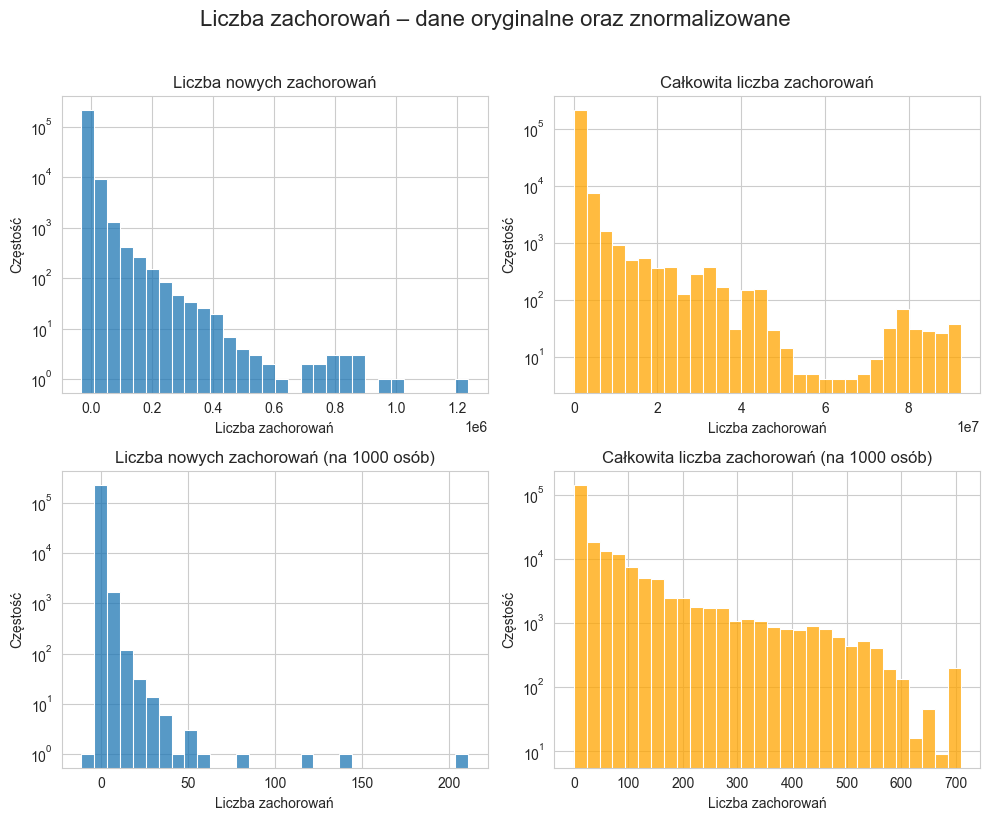

In [53]:
fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(10, 8)
)

sns.histplot(df_normalized_countries, x='new_confirmed', bins=30, ax=axes[0][0])
axes[0][0].set_title('Liczba nowych zachorowań')

sns.histplot(df_normalized_countries, x='new_confirmed_per_1000', bins=30, ax=axes[1][0])
axes[1][0].set_title('Liczba nowych zachorowań (na 1000 osób)')

sns.histplot(df_normalized_countries, x='cumulative_confirmed', bins=30, ax=axes[0][1], color='orange')
axes[0][1].set_title('Całkowita liczba zachorowań')

sns.histplot(df_normalized_countries, x='cumulative_confirmed_per_1000', bins=30, ax=axes[1][1], color='orange')
axes[1][1].set_title('Całkowita liczba zachorowań (na 1000 osób)')

for ax in axes.flatten():
    ax.set_yscale('log')
    ax.set_xlabel('Liczba zachorowań')
    ax.set_ylabel('Częstość')

fig.suptitle(
    'Liczba zachorowań – dane oryginalne oraz znormalizowane',
    fontsize=16, y=1.02
)

plt.tight_layout()
plt.show()

##### **Ad. 4.2.**

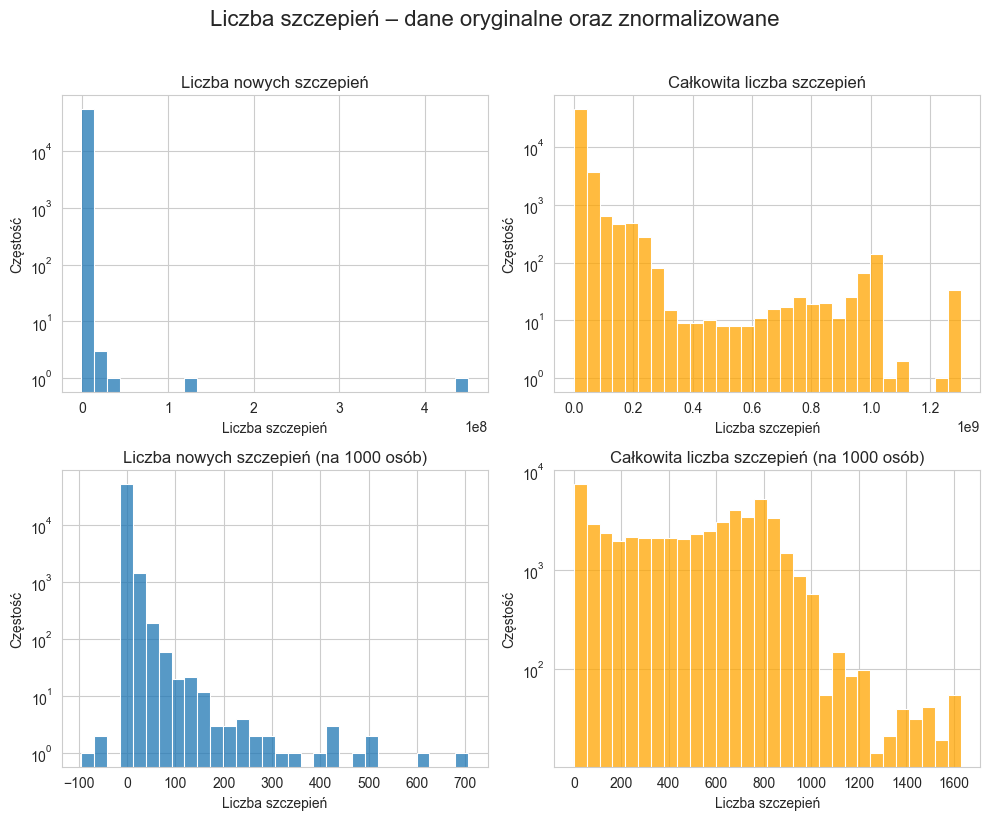

In [54]:
fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(10, 8)
)

sns.histplot(df_normalized_countries, x='new_persons_vaccinated', bins=30, ax=axes[0][0])
axes[0][0].set_title('Liczba nowych szczepień')

sns.histplot(df_normalized_countries, x='new_persons_vaccinated_per_1000', bins=30, ax=axes[1][0])
axes[1][0].set_title('Liczba nowych szczepień (na 1000 osób)')

sns.histplot(df_normalized_countries, x='cumulative_persons_vaccinated', bins=30, ax=axes[0][1], color='orange')
axes[0][1].set_title('Całkowita liczba szczepień')

sns.histplot(df_normalized_countries, x='cumulative_persons_vaccinated_per_1000', bins=30, ax=axes[1][1], color='orange')
axes[1][1].set_title('Całkowita liczba szczepień (na 1000 osób)')

for ax in axes.flatten():
    ax.set_yscale('log')
    ax.set_xlabel('Liczba szczepień')
    ax.set_ylabel('Częstość')

fig.suptitle(
    'Liczba szczepień – dane oryginalne oraz znormalizowane',
    fontsize=16, y=1.02
)

plt.tight_layout()
plt.show()

##### **Ad. 4.3.**

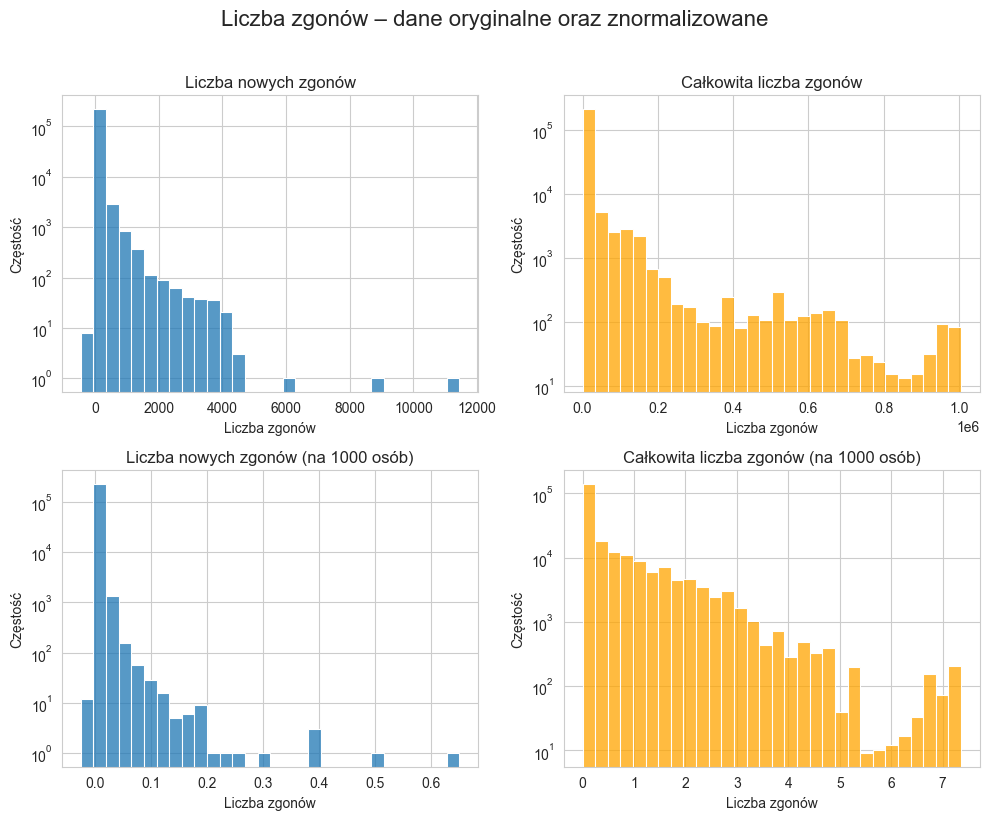

In [55]:
fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(10, 8)
)

sns.histplot(df_normalized_countries, x='new_deceased', bins=30, ax=axes[0][0])
axes[0][0].set_title('Liczba nowych zgonów')

sns.histplot(df_normalized_countries, x='new_deceased_per_1000', bins=30, ax=axes[1][0])
axes[1][0].set_title('Liczba nowych zgonów (na 1000 osób)')

sns.histplot(df_normalized_countries, x='cumulative_deceased', bins=30, ax=axes[0][1], color='orange')
axes[0][1].set_title('Całkowita liczba zgonów')

sns.histplot(df_normalized_countries, x='cumulative_deceased_per_1000', bins=30, ax=axes[1][1], color='orange')
axes[1][1].set_title('Całkowita liczba zgonów (na 1000 osób)')

for ax in axes.flatten():
    ax.set_yscale('log')
    ax.set_xlabel('Liczba zgonów')
    ax.set_ylabel('Częstość')

fig.suptitle(
    'Liczba zgonów – dane oryginalne oraz znormalizowane',
    fontsize=16, y=1.02
)

plt.tight_layout()
plt.show()

##### **Ad. 4.4.**

1. Generacja i zapotrzebowanie energii elektrycznej:

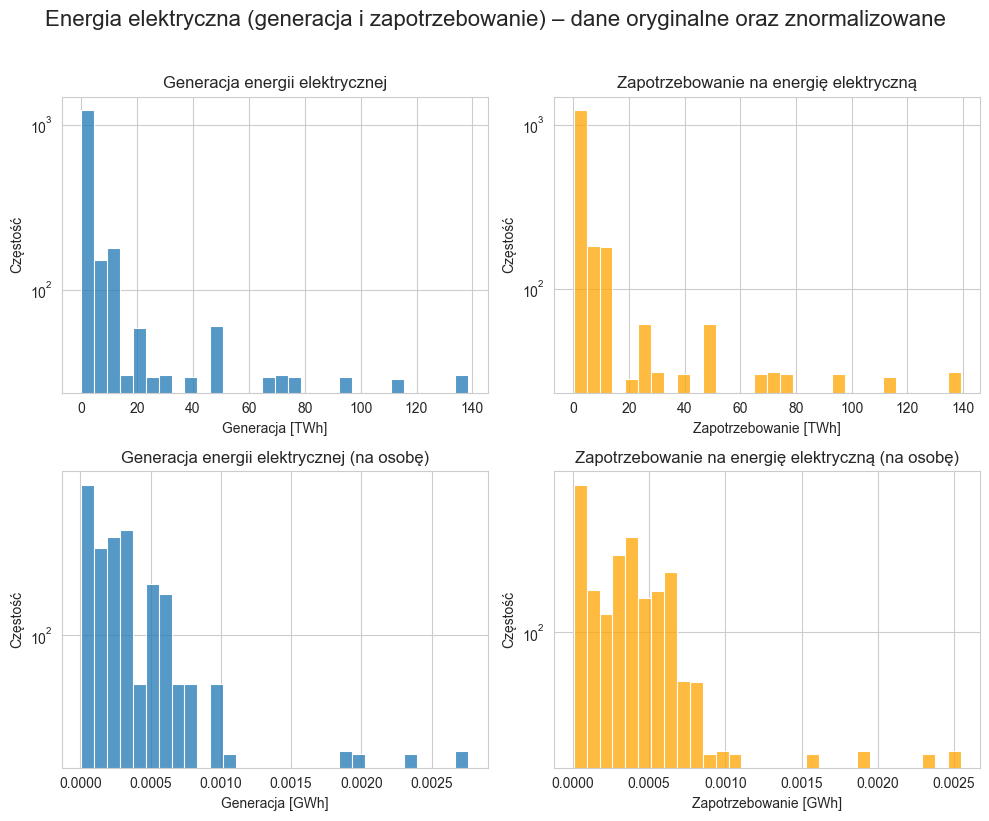

In [56]:
fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(10, 8)
)

sns.histplot(df_normalized_countries, x='country_electricity_generation_twh_monthly', bins=30, ax=axes[0][0])
axes[0][0].set_xlabel('Generacja [TWh]')
axes[0][0].set_title('Generacja energii elektrycznej')

sns.histplot(df_normalized_countries, x='country_electricity_generation_per_person_gwh', bins=30, ax=axes[1][0])
axes[1][0].set_xlabel('Generacja [GWh]')
axes[1][0].set_title('Generacja energii elektrycznej (na osobę)')

sns.histplot(df_normalized_countries, x='country_electricity_demand_twh_monthly', bins=30, ax=axes[0][1], color='orange')
axes[0][1].set_xlabel('Zapotrzebowanie [TWh]')
axes[0][1].set_title('Zapotrzebowanie na energię elektryczną')

sns.histplot(df_normalized_countries, x='country_electricity_demand_per_person_gwh', bins=30, ax=axes[1][1], color='orange')
axes[1][1].set_xlabel('Zapotrzebowanie [GWh]')
axes[1][1].set_title('Zapotrzebowanie na energię elektryczną (na osobę)')

for ax in axes.flatten():
    ax.set_yscale('log')
    ax.set_ylabel('Częstość')

fig.suptitle(
    'Energia elektryczna (generacja i zapotrzebowanie) – dane oryginalne oraz znormalizowane',
    fontsize=16, y=1.02
)

plt.tight_layout()
plt.show()

2. Indeks jakości powietrza (AQI):

In [57]:
df_normalized_us_counties = df_combined.query(
    "iso_3166_1_alpha_2 == 'US' & aggregation_level == 2"
)

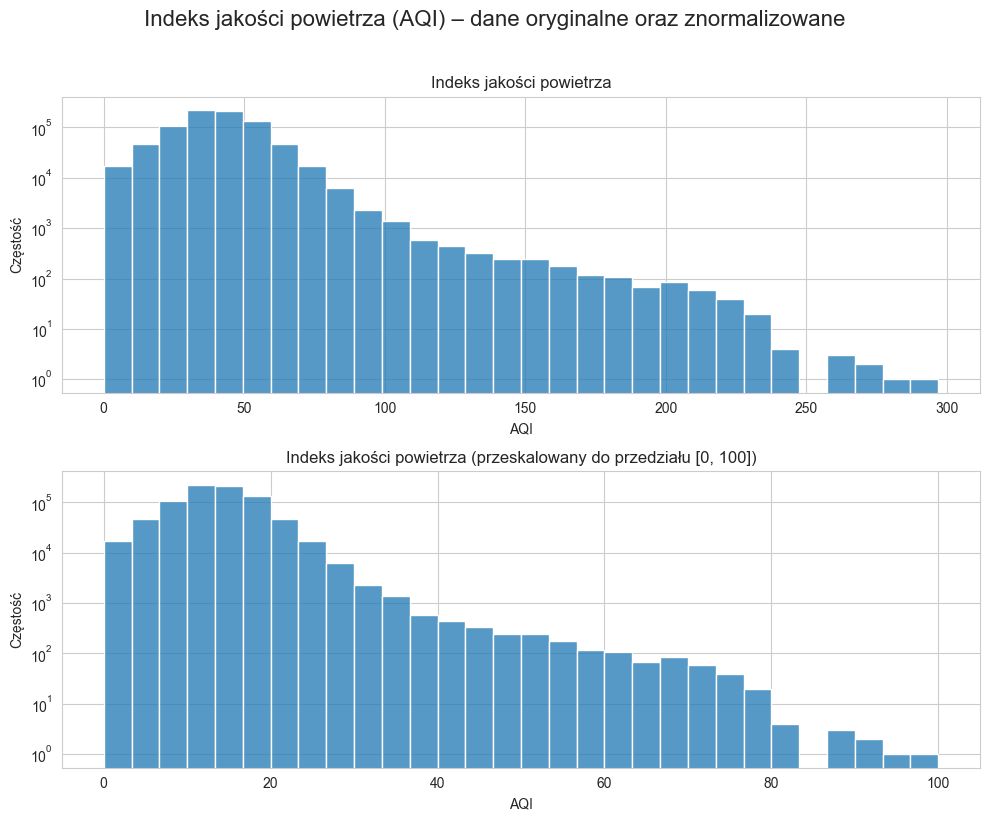

In [58]:
fig, axes = plt.subplots(
    nrows=2,
    figsize=(10, 8)
)

sns.histplot(df_normalized_us_counties, x='aqi_daily', bins=30, ax=axes[0])
axes[0].set_title('Indeks jakości powietrza')

sns.histplot(df_normalized_us_counties, x='aqi_daily_normalized', bins=30, ax=axes[1])
axes[1].set_title('Indeks jakości powietrza (przeskalowany do przedziału [0, 100])')

for ax in axes.flatten():
    ax.set_yscale('log')
    ax.set_xlabel('AQI')
    ax.set_ylabel('Częstość')

fig.suptitle(
    'Indeks jakości powietrza (AQI) – dane oryginalne oraz znormalizowane',
    fontsize=16, y=1.02
)

plt.tight_layout()
plt.show()

3. PKB:

In [59]:
df_normalized_countries_yearly = df_normalized_countries.copy()

df_normalized_countries_yearly['date'] = pd.to_datetime(
    df_normalized_countries_yearly['date']
)

df_normalized_countries_yearly['year'] = df_normalized_countries_yearly['date'].dt.year

df_normalized_countries_yearly = df_normalized_countries_yearly.drop_duplicates(
    subset=['country_name', 'year']
)

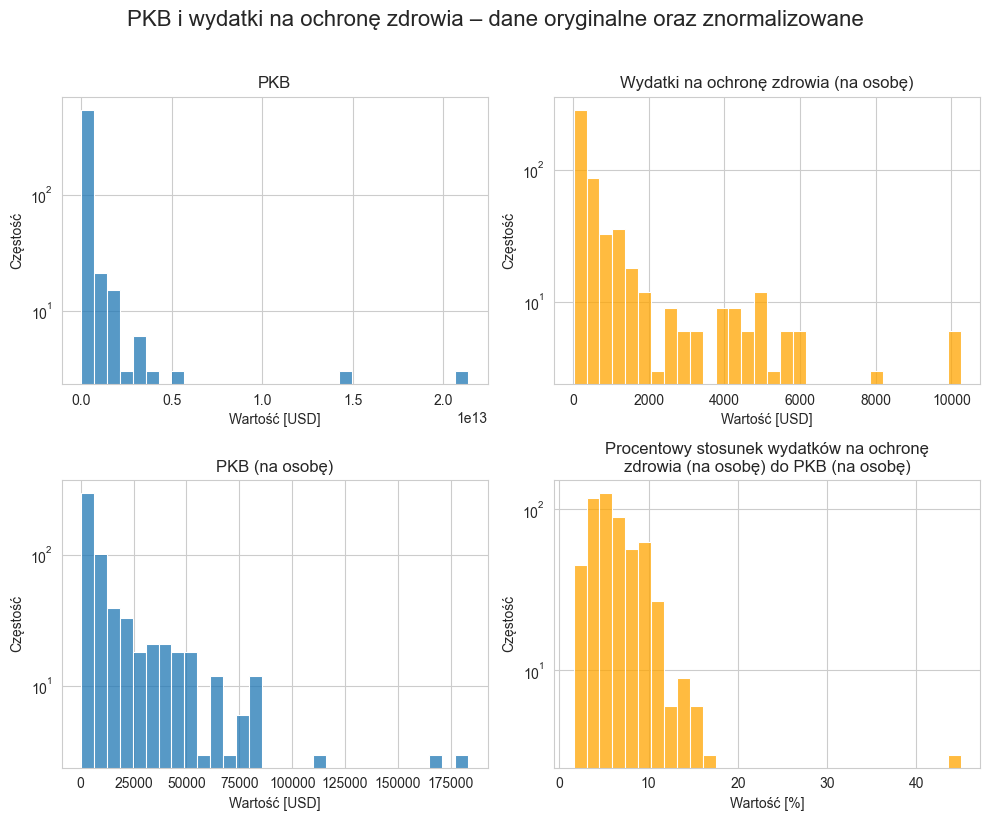

In [60]:
fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(10, 8)
)

sns.histplot(df_normalized_countries_yearly, x='gdp_usd', bins=30, ax=axes[0][0])
axes[0][0].set_xlabel('Wartość [USD]')
axes[0][0].set_title('PKB')

sns.histplot(df_normalized_countries_yearly, x='gdp_per_capita', bins=30, ax=axes[1][0])
axes[1][0].set_xlabel('Wartość [USD]')
axes[1][0].set_title('PKB (na osobę)')

sns.histplot(df_normalized_countries_yearly, x='health_expenditure_usd', bins=30, ax=axes[0][1], color='orange')
axes[0][1].set_xlabel('Wartość [USD]')
axes[0][1].set_title('Wydatki na ochronę zdrowia (na osobę)')

sns.histplot(df_normalized_countries_yearly, x='health_expenditure_pct_gdp', bins=30, ax=axes[1][1], color='orange')
axes[1][1].set_xlabel('Wartość [%]')
axes[1][1].set_title('Procentowy stosunek wydatków na ochronę\n'
                     'zdrowia (na osobę) do PKB (na osobę)')

for ax in axes.flatten():
    ax.set_yscale('log')
    ax.set_ylabel('Częstość')

fig.suptitle(
    'PKB i wydatki na ochronę zdrowia – dane oryginalne oraz znormalizowane',
    fontsize=16, y=1.02
)

plt.tight_layout()
plt.show()

4. Trendy wyszukiwań:

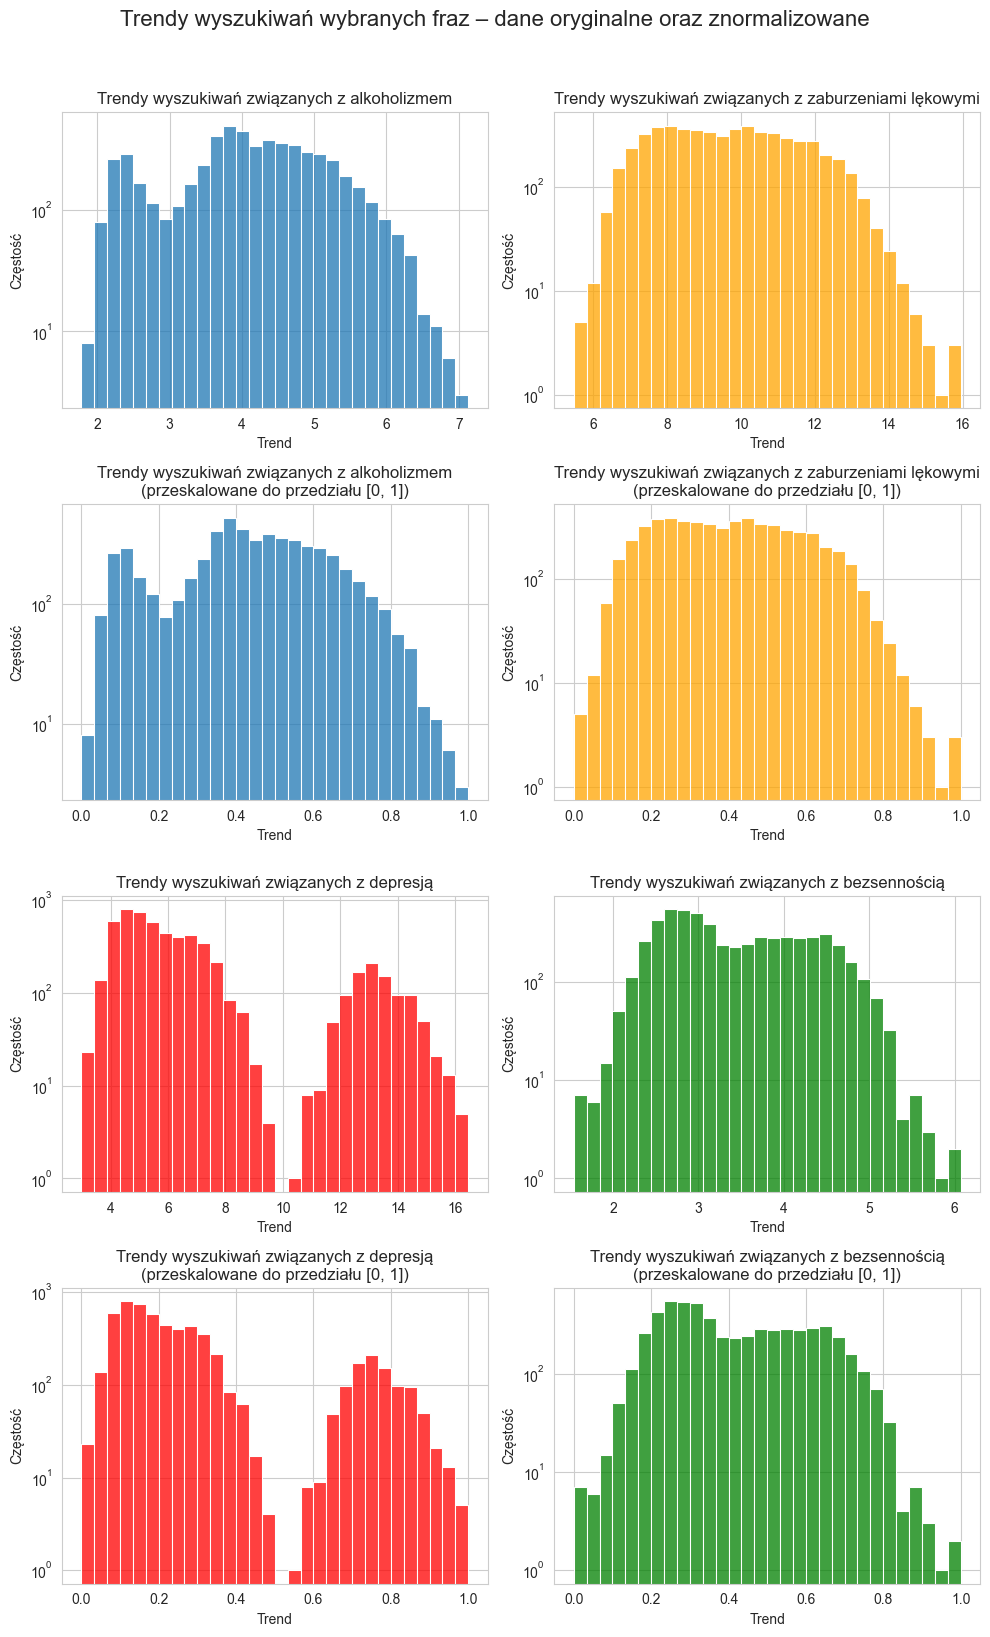

In [61]:
fig, axes = plt.subplots(
    nrows=4, ncols=2,
    figsize=(10, 16)
)

sns.histplot(df_normalized_countries, x='search_trends_alcoholism', bins=30, ax=axes[0][0])
axes[0][0].set_title("Trendy wyszukiwań związanych z alkoholizmem")

sns.histplot(df_normalized_countries, x='search_trends_alcoholism_normalized', bins=30, ax=axes[1][0])
axes[1][0].set_title("Trendy wyszukiwań związanych z alkoholizmem\n"
                     "(przeskalowane do przedziału [0, 1])")

sns.histplot(df_normalized_countries, x='search_trends_anxiety', bins=30, ax=axes[0][1], color='orange')
axes[0][1].set_title("Trendy wyszukiwań związanych z zaburzeniami lękowymi")

sns.histplot(df_normalized_countries, x='search_trends_anxiety_normalized', bins=30, ax=axes[1][1], color='orange')
axes[1][1].set_title("Trendy wyszukiwań związanych z zaburzeniami lękowymi\n"
                     "(przeskalowane do przedziału [0, 1])")

sns.histplot(df_normalized_countries, x='search_trends_depression', bins=30, ax=axes[2][0], color='red')
axes[2][0].set_title("Trendy wyszukiwań związanych z depresją")

sns.histplot(df_normalized_countries, x='search_trends_depression_normalized', bins=30, ax=axes[3][0], color='red')
axes[3][0].set_title("Trendy wyszukiwań związanych z depresją\n"
                     "(przeskalowane do przedziału [0, 1])")

sns.histplot(df_normalized_countries, x='search_trends_insomnia', bins=30, ax=axes[2][1], color='green')
axes[2][1].set_title("Trendy wyszukiwań związanych z bezsennością")

sns.histplot(df_normalized_countries, x='search_trends_insomnia_normalized', bins=30, ax=axes[3][1], color='green')
axes[3][1].set_title("Trendy wyszukiwań związanych z bezsennością\n"
                     "(przeskalowane do przedziału [0, 1])")

for ax in axes.flatten():
    ax.set_yscale('log')
    ax.set_xlabel('Trend')
    ax.set_ylabel('Częstość')

fig.suptitle(
    'Trendy wyszukiwań wybranych fraz – dane oryginalne oraz znormalizowane',
    fontsize=16, y=1.02
)

plt.tight_layout()
plt.show()

## Część 5
**Misja dodatkowa — Korelacja danych**

***Współczynnik korelacji** przedstawia związek pomiędzy dwoma zmiennymi, co pozwala na zaobserwowanie potencjalnych zależności pomiędzy informacjami.*

Stwórz macierze korelacji, które przedstawią współczynniki korelacji dla każdej pary zmiennych:

#### **5.1.** liczba nowych zachorowań, szczepień i zgonów, a liczba nowych zachorowań, szczepień i zgonów,

In [62]:
def plot_correlation_matrix(corr_matrix, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
    plt.title(title, fontsize=16, pad=20)
    plt.show()

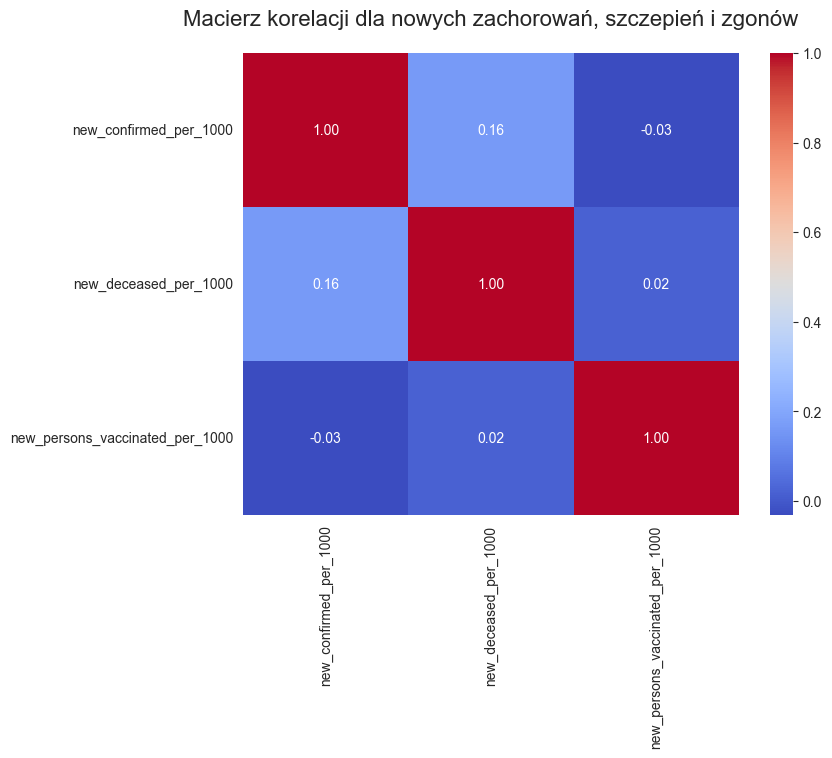

In [63]:
df_corr_1 = df_normalized_countries[[
    'new_confirmed_per_1000', 'new_deceased_per_1000', 'new_persons_vaccinated_per_1000'
]].corr()

plot_correlation_matrix(
    df_corr_1,
    'Macierz korelacji dla nowych zachorowań, szczepień i zgonów'
)

#### **5.2.** liczba nowych zachorowań, szczepień, zgonów, a łączna liczba zachorowań, szczepień, zgonów,

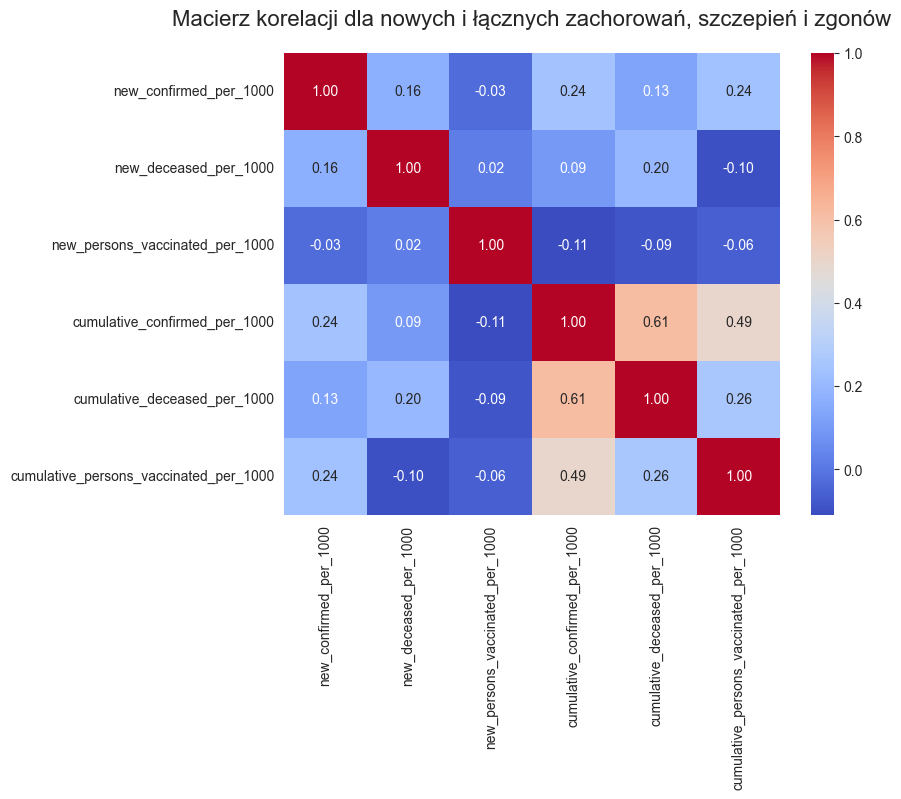

In [64]:
df_corr_2 = df_normalized_countries[[
    'new_confirmed_per_1000', 'new_deceased_per_1000', 'new_persons_vaccinated_per_1000', 'cumulative_confirmed_per_1000', 'cumulative_deceased_per_1000', 'cumulative_persons_vaccinated_per_1000'
]].corr()

plot_correlation_matrix(
    df_corr_2,
    'Macierz korelacji dla nowych i łącznych zachorowań, szczepień i zgonów'
)

#### **5.3.** wskaźniki gospodarcze, a liczba nowych zachorowań, szczepień i zgonów,

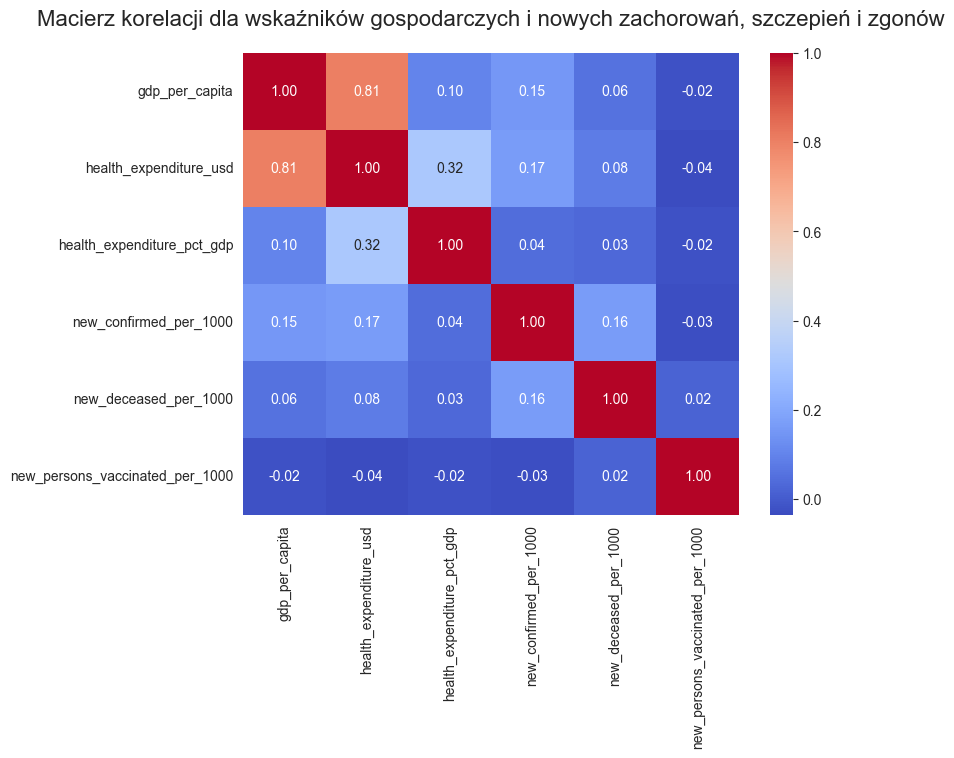

In [65]:
df_corr_3 = df_normalized_countries[[
    'gdp_per_capita', 'health_expenditure_usd', 'health_expenditure_pct_gdp', 'new_confirmed_per_1000', 'new_deceased_per_1000', 'new_persons_vaccinated_per_1000'
]].corr()

plot_correlation_matrix(
    df_corr_3,
    'Macierz korelacji dla wskaźników gospodarczych i nowych zachorowań, szczepień i zgonów'
)

#### **5.4.** parametry demograficzne, a liczba nowych zachorowań, szczepień i zgonów,

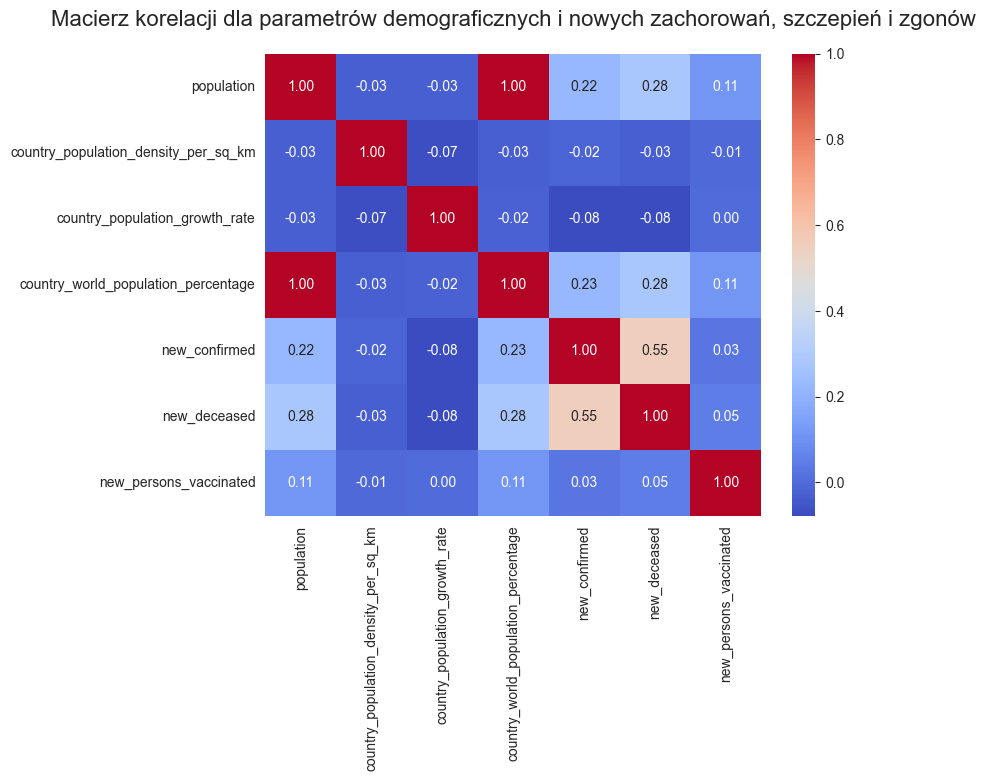

In [66]:
df_corr_4 = df_normalized_countries[[
    'population', 'country_population_density_per_sq_km', 'country_population_growth_rate', 'country_world_population_percentage', 'new_confirmed', 'new_deceased', 'new_persons_vaccinated'
]].corr()

plot_correlation_matrix(
    df_corr_4,
    'Macierz korelacji dla parametrów demograficznych i nowych zachorowań, szczepień i zgonów'
)

#### **5.5.** co najmniej 4 dodatkowe korelacje pomiędzy różnymi danymi.

##### 1. Generacja i zapotrzebowanie energii elektrycznej na osobę, a liczba nowych zachorowań, szczepień i zgonów.

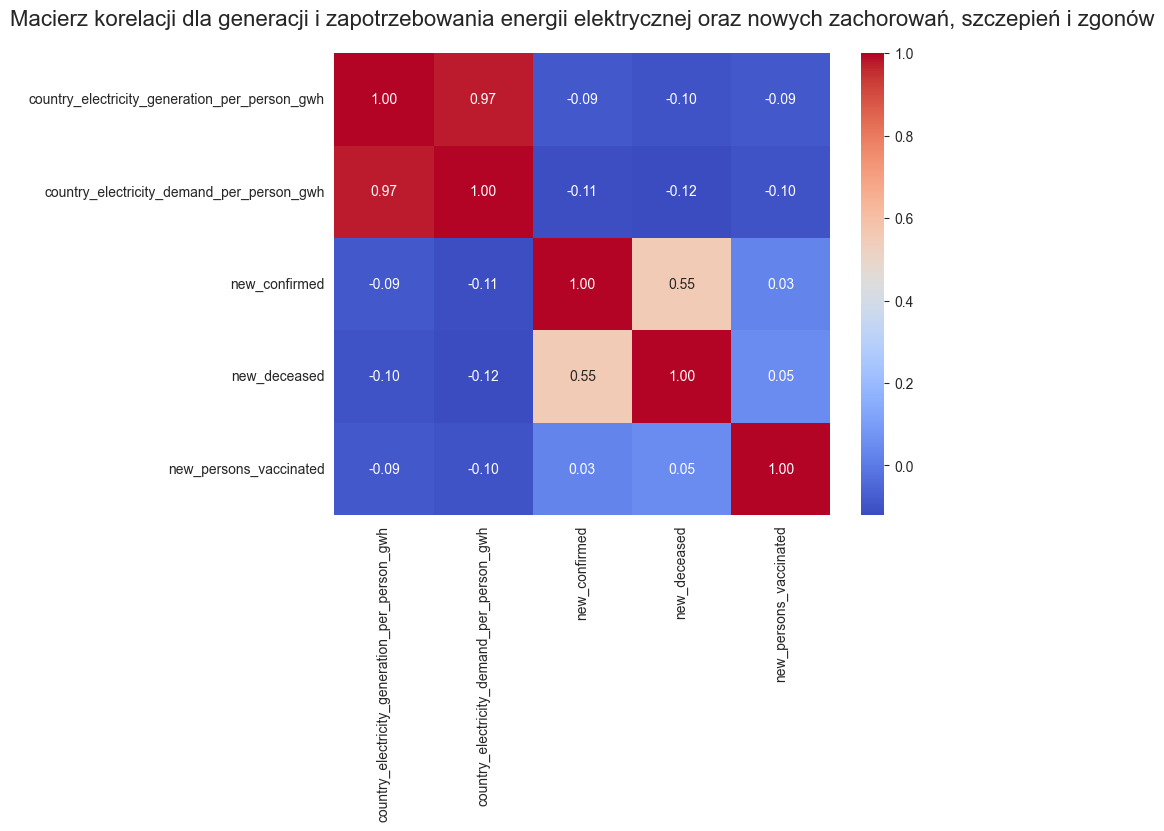

In [67]:
df_corr_5 = df_normalized_countries[[
    'country_electricity_generation_per_person_gwh', 'country_electricity_demand_per_person_gwh', 'new_confirmed', 'new_deceased', 'new_persons_vaccinated'
]].corr()

plot_correlation_matrix(
    df_corr_5,
    'Macierz korelacji dla generacji i zapotrzebowania energii elektrycznej oraz nowych zachorowań, szczepień i zgonów'
)

##### 2. Indeks jakości powietrza (AQI) a liczba nowych zachorowań i zgonów.

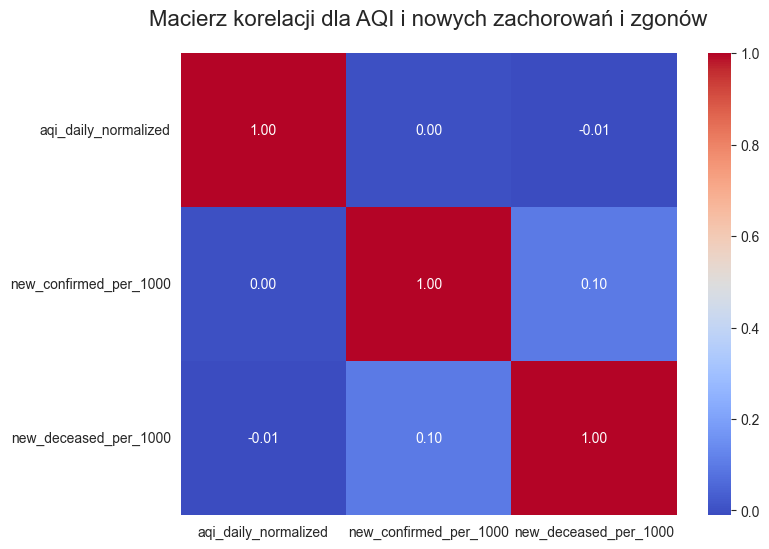

In [68]:
df_corr_6 = df_normalized_us_counties[[
    'aqi_daily_normalized', 'new_confirmed_per_1000', 'new_deceased_per_1000'
]].corr()

plot_correlation_matrix(
    df_corr_6,
    'Macierz korelacji dla AQI i nowych zachorowań i zgonów'
)

##### 3. Wskaźniki gospodarcze a zasoby medyczne.

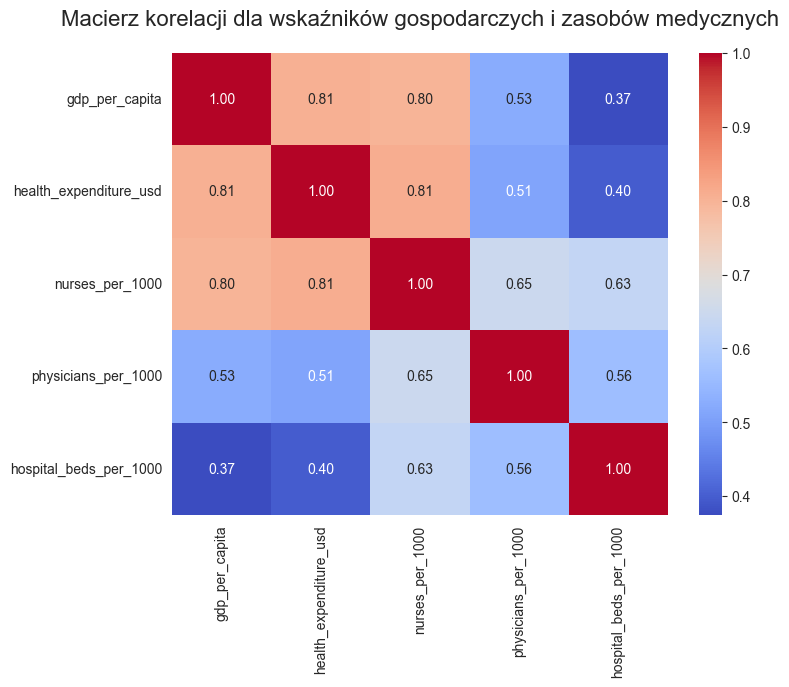

In [69]:
df_corr_7 = df_normalized_countries[[
    'gdp_per_capita', 'health_expenditure_usd', 'nurses_per_1000', 'physicians_per_1000', 'hospital_beds_per_1000'
]].corr()

plot_correlation_matrix(
    df_corr_7,
    'Macierz korelacji dla wskaźników gospodarczych i zasobów medycznych'
)

##### 4. Trendy wyszukiwań a liczba nowych zachorowań, szczepień i zgonów.

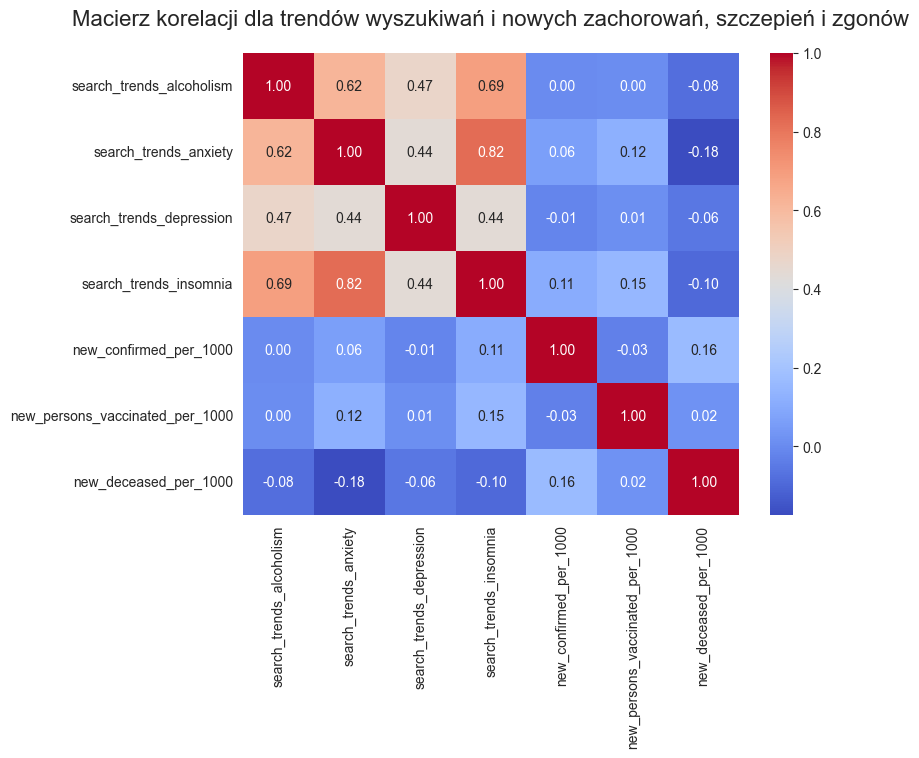

In [70]:
df_corr_8 = df_normalized_countries[[
    'search_trends_alcoholism', 'search_trends_anxiety', 'search_trends_depression', 'search_trends_insomnia', 'new_confirmed_per_1000', 'new_persons_vaccinated_per_1000', 'new_deceased_per_1000'
]].corr()

plot_correlation_matrix(
    df_corr_8,
    'Macierz korelacji dla trendów wyszukiwań i nowych zachorowań, szczepień i zgonów'
)